# This notebook plots:
- Total & MCS precipitation Hovmoller diagram
- Total & MCS precipitation domain mean time series

In [1]:
import numpy as np
import glob, os
import xarray as xr
import pandas as pd
import time, datetime, calendar, pytz
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import shapely.geometry as sgeom
import colormath, colormath.color_objects, colormath.color_conversions
from colormath.color_objects import sRGBColor
import urllib
import re
# from sklearn.metrics import mean_squared_error
%matplotlib inline

In [2]:
# Boundary used for calculating domain mean time series rainfall
startlon = -107
endlon = -90

# Sepcify directory of the MCS stats file
rootdir = '/pscratch/sd/w/wcmca1/SCREAM-cess/'
gpmdir = f'{rootdir}gpm/stats/monthly/'
m1dir = f'{rootdir}control_nudged/stats/monthly/'
m2dir = f'{rootdir}control_free/stats/monthly/'
region = 'CUS'

name_map1 = {'obs':'OBS', 'm1':'EAMxx-Nudged', 'm2':'EAMxx-Free'}
name_map2 = {'obs':'OBS', 'm1':'EAMxx-N', 'm2':'EAMxx-F'}

datetime_range = pd.to_datetime(['2019-09-01T00', '2020-09-01T00'])
dates = pd.date_range(start=min(datetime_range), end=max(datetime_range), freq='MS').strftime('%Y%m')
    
# Find all files from the list of dates
m1files = []
m2files = []
gpmfiles = []

for dd in dates:
    m1files = m1files + sorted(glob.glob(f'{m1dir}mcs_rainhov_{region}_{dd}*.nc'))
    m2files = m2files + sorted(glob.glob(f'{m2dir}mcs_rainhov_{region}_{dd}*.nc'))
    gpmfiles = gpmfiles + sorted(glob.glob(f'{gpmdir}mcs_rainhov_{region}_{dd}*.nc'))

# nyears_gpm = 1
# nyears_m1 = 1
# nyears_m2 = 1
nfiles_gpm = len(gpmfiles)
nfiles_m1 = len(m1files)
nfiles_m2 = len(m2files)
print(f'Number of files (OBS): {nfiles_gpm}')
print(f'Number of files (m1): {nfiles_m1}')
print(f'Number of files (m2): {nfiles_m2}')

figdir = f'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

# rootdir = '/global/cfs/cdirs/m2637/zfeng/sgp_flood/'

# grddir = f'{rootdir}obs/stats/'
# nldasdir = f'{rootdir}obs/nldas/stats/'
# wrfctl_dir = f'{rootdir}/ctl/stats/'
# wrfpgw_dir = f'{rootdir}/pgw/stats/'

# grdpcpfile = f'{grddir}mcs_rainhov_201505.nc'
# nldaspcpfile = f'{nldasdir}mcs_rainhov_201505.nc'
# wrfctl_pcpfile = f'{wrfctl_dir}mcs_rainhov_201505.nc'
# wrfpgw_pcpfile = f'{wrfpgw_dir}mcs_rainhov_201505.nc'

# grdmcsfile = f'{grddir}mcs_tracks_final_20150503.0000_20150601.0000.nc'
# wrfctl_mcsfile = f'{wrfctl_dir}/mcs_tracks_final_20150503.0000_20150601.0000.nc'
# wrfpgw_mcsfile = f'{wrfpgw_dir}/mcs_tracks_final_20150503.0000_20150601.0000.nc'

# wrfmapfile = f'{rootdir}/ctl/map_data/wrf_landmask.nc'

# figdir = f'/global/cfs/cdirs/m2637/zfeng/sgp_flood/figures/'
# os.makedirs(figdir, exist_ok=True)
# print(figdir)

Number of files (OBS): 6
Number of files (m1): 6
Number of files (m2): 6
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/


In [3]:
# # Boundary used for calculating domain mean time series rainfall
# startlon = -107
# endlon = -90

# rootdir = '/global/cfs/cdirs/m2637/zfeng/sgp_flood/'

# grddir = f'{rootdir}obs/stats/'
# nldasdir = f'{rootdir}obs/nldas/stats/'
# wrfctl_dir = f'{rootdir}/ctl/stats/'
# wrfpgw_dir = f'{rootdir}/pgw/stats/'

# grdpcpfile = f'{grddir}mcs_rainhov_201505.nc'
# nldaspcpfile = f'{nldasdir}mcs_rainhov_201505.nc'
# wrfctl_pcpfile = f'{wrfctl_dir}mcs_rainhov_201505.nc'
# wrfpgw_pcpfile = f'{wrfpgw_dir}mcs_rainhov_201505.nc'

# grdmcsfile = f'{grddir}mcs_tracks_final_20150503.0000_20150601.0000.nc'
# wrfctl_mcsfile = f'{wrfctl_dir}/mcs_tracks_final_20150503.0000_20150601.0000.nc'
# wrfpgw_mcsfile = f'{wrfpgw_dir}/mcs_tracks_final_20150503.0000_20150601.0000.nc'

# wrfmapfile = f'{rootdir}/ctl/map_data/wrf_landmask.nc'

# figdir = f'/global/cfs/cdirs/m2637/zfeng/sgp_flood/figures/'
# os.makedirs(figdir, exist_ok=True)
# print(figdir)

/global/cfs/cdirs/m2637/zfeng/sgp_flood/figures/


In [3]:
# # Get WRF domain
# dswrf = xr.open_dataset(wrfmapfile)
# wrflat_min, wrflat_max = dswrf.XLAT.min().values, dswrf.XLAT.max().values
# wrflon_min, wrflon_max = dswrf.XLONG.min().values, dswrf.XLONG.max().values
# print(wrflon_min, wrflon_max, wrflat_min, wrflat_max)

In [4]:
# # Get WRF domain 4 corner lat/lon
# XLAT = dswrf.XLAT.squeeze()
# XLONG = dswrf.XLONG.squeeze()
# wlat_ll, wlon_ll = XLAT[0,0].item(), XLONG[0,0].item()
# wlat_lr, wlon_lr = XLAT[0,-1].item(), XLONG[0,-1].item()
# print(wlon_ll, wlon_lr, wlat_ll, wlat_lr)

# wlat_ul, wlon_ul = XLAT[-1,0].item(), XLONG[-1,0].item()
# wlat_ur, wlon_ur = XLAT[-1,-1].item(), XLONG[-1,-1].item()
# print(wlon_ul, wlon_ur, wlat_ul, wlat_ur)

In [6]:
# ds_grd = xr.open_dataset(grdpcpfile)
# lon_grd = ds_grd.lon
# startlat = ds_grd.attrs['startlat']
# endlat = ds_grd.attrs['endlat']
# ds_grd

In [7]:
# ds_w1 = xr.open_dataset(wrfctl_pcpfile)
# lon_wrf = ds_w1.lon
# ds_w1

In [5]:
# Read OBS data
dsobs = xr.open_mfdataset(gpmfiles, concat_dim='time', combine='nested')
lon_obs = dsobs.lon
startlat = dsobs.attrs['startlat']
endlat = dsobs.attrs['endlat']
dsobs

<xarray.Dataset> Size: 11MB
Dimensions:            (time: 4416, lon: 300)
Coordinates:
  * lon                (lon) float64 2kB -109.9 -109.8 -109.8 ... -80.15 -80.05
  * time               (time) datetime64[ns] 35kB 2020-03-01T00:30:00 ... 202...
Data variables:
    precipitation      (time, lon) float32 5MB dask.array<chunksize=(1, 300), meta=np.ndarray>
    mcs_precipitation  (time, lon) float32 5MB dask.array<chunksize=(1, 300), meta=np.ndarray>
Attributes:
    title:       MCS precipitation Hovmoller
    startlat:    30.0
    endlat:      49.0
    startlon:    -110.0
    endlon:      -80.0
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    created_on:  Tue Aug 27 11:46:47 2024

In [8]:
# Read m1 data
dsm1 = xr.open_mfdataset(m1files, concat_dim='time', combine='nested')
lon_m1 = dsm1.lon

In [9]:
# Read m2 data
dsm2 = xr.open_mfdataset(m2files, concat_dim='time', combine='nested')
lon_m2 = dsm2.lon

In [10]:
# ds_nld = xr.open_dataset(nldaspcpfile)
# lon_nld = ds_nld.lon
# ds_nld

## Custom function to use NCL colormaps

In [11]:
color_obj_dict = {'sRGB':colormath.color_objects.sRGBColor,
                  'HSV':colormath.color_objects.HSVColor,
                  'Lab':colormath.color_objects.LabColor,
                  'LCHuv':colormath.color_objects.LCHuvColor,
                  'LCHab':colormath.color_objects.LCHabColor,
                  'XYZ':colormath.color_objects.XYZColor}

def __rgb_to_array(rgb_color):
    r = np.minimum(1, round(rgb_color.rgb_r*10000)/10000)
    g = np.minimum(1, round(rgb_color.rgb_g*10000)/10000)
    b = np.minimum(1, round(rgb_color.rgb_b*10000)/10000)
    return r,g,b


def create_palette(start_rgb, end_rgb, n, colorspace):
    # convert start and end to a point in the given colorspace
    start = colormath.color_conversions.convert_color(start_rgb, colorspace).get_value_tuple()
    end = colormath.color_conversions.convert_color(end_rgb, colorspace).get_value_tuple()

    # create a set of n points along start to end
    points = list(zip(*[np.linspace(start[i], end[i], n) for i in range(3)]))

    # create a color for each point and convert back to rgb
    rgb_colors = [colormath.color_conversions.convert_color(colorspace(*point), sRGBColor) for point in points]

    # finally convert rgb colors back to hex
    return [__rgb_to_array(color) for color in  rgb_colors]


def __retrive_NCL_webcontent(cmapname):
    target_url = 'https://www.ncl.ucar.edu/Document/Graphics/ColorTables/Files/%s.rgb' % cmapname
    request = urllib.request.urlopen(target_url)
    return request


def __collect_discrete_NCL_cmap(cmapname):
    rawdata = __retrive_NCL_webcontent(cmapname)
    
    cmap_color_list = list()
    
    color_section_sig = 0
    
    for line in rawdata:
        
        line_decode = line.decode('utf-8')
        info = re.split('\s+', line_decode.replace('\n','').replace('^\s+',''))

        if color_section_sig==1:
            if info[0]=='' and len(info)>=3:
                if np.maximum(np.maximum(float(info[1]), float(info[2])), float(info[3]))>1:
                    cmap_color_list.append((float(info[1])/255, float(info[2])/255, float(info[3])/255))
                else:
                    cmap_color_list.append((float(info[1]), float(info[2]), float(info[3])))
            if len(info)==3:
                if ';' in info[0] or '#' in info[0]:
                    whatisthis = 's'
                else:
                    if np.maximum(np.maximum(float(info[0]), float(info[1])), float(info[2]))>1:
                        cmap_color_list.append((float(info[0])/255, float(info[1])/255, float(info[2])/255))
                    else:
                        cmap_color_list.append((float(info[0]), float(info[1]), float(info[2])))
        
        if 'ncolors' in str(info[0]):
            color_section_sig = 1  # meaning now we are at color lines (or "r g b" line)

    return cmap_color_list


def __cmap_refinement(raw_cmap_rgb, n_interpolate=10, workspace=color_obj_dict['sRGB']):
    # workspace:  choose which color space the refinement is conducted.
    #             refer to https://stackoverflow.com/questions/55032648/given-a-start-color-and-a-middle-color-how-to-get-the-remaining-colors-python

    n_in = len(raw_cmap_rgb)

    new_array = list()

    for i in np.arange(n_in-1):
        out_colors = create_palette(sRGBColor(*raw_cmap_rgb[i], is_upscaled=False), sRGBColor(*raw_cmap_rgb[i+1], is_upscaled=False), n_interpolate+1, workspace)
        for j in np.arange(len(out_colors)-1):
            new_array.append(out_colors[j])

    return new_array


def generate_NCL_cmap(cmapname, cont_opt=False, cont_param_n=10, cont_param_ws='sRGB',
                      white_first=False, white_ext=False, reverse_cmap=False):
    # description:
    #     cmapname:      taken as shown on the NCL website
    #     cont_opt:      to convert the discreate colormap to continuous colormap
    #     cont_param_n:  how many "intermediate" colors to be inserted to the nearby discreate colors
    #     cont_param_ws: color space to conduct interploation. Default to "sRGB", which should work for most cases
    #     white_first:   whether to set the first color as white. May be useful if the minimum does not mean anything
    #     white_ext:     whether to add this above white as an extended color (when set to True), or just replace the first color (when set to False).
    #     reverse_cmap:  similar to "_r" in colormap.
    # note:  reverse_cmap is applied first, then white_first option.

    cmap_discrete_raw = __collect_discrete_NCL_cmap(cmapname)

    if reverse_cmap==True:
        cmap_discrete_raw.reverse()

    if white_first==True:
        if white_ext==True:
            cmap_discrete = list()
            cmap_discrete.append((1,1,1))
            for i in np.arange(len(cmap_discrete_raw)):
                cmap_discrete.append(cmap_discrete_raw[int(i)])
        else:
            cmap_discrete = cmap_discrete_raw.copy()
        cmap_discrete[0] = (1,1,1)
    else:
        cmap_discrete = cmap_discrete_raw

    if cont_opt==False:
        out_cmap = cmap_discrete

    if cont_opt==True:
        out_cmap = __cmap_refinement(cmap_discrete, n_interpolate=cont_param_n, workspace=color_obj_dict[cont_param_ws])

    return mpl.colors.ListedColormap(out_cmap)

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [13]:
lon_obs.min(), lon_obs.max(), lon_m1.min(), lon_m1.max()

(<xarray.DataArray 'lon' ()> Size: 8B
 array(-109.95),
 <xarray.DataArray 'lon' ()> Size: 8B
 array(-80.05),
 <xarray.DataArray 'lon' ()> Size: 8B
 array(-109.95),
 <xarray.DataArray 'lon' ()> Size: 8B
 array(-80.05))

## Function to plot 3 Hovmoller plots with 2 colorbars

In [14]:
# def plot_3hov_2cb(dataarr, lonarr, timearr, levels, cmaps, titles, ylabels, cblabels, figname, fillmiss=False):

#     mpl.rcParams['font.size'] = 14
#     mpl.rcParams['font.family'] = 'Helvetica'

#     fig, axs = plt.subplots(1, 3, figsize=[15,13], dpi=100)
#     pcm_save = []

#     dom = np.arange(1, 32, 1, dtype='int16')
#     # dfmt = mpl.dates.DateFormatter('%m/%d')
#     dfmt = mpl.dates.DateFormatter('%d')
#     days = mpl.dates.DayLocator(bymonthday=dom)
#     xlims = (-110, -85)
#     xtickvals = np.arange(-105, -85.1, 5)
    
#     miss_sdate = '2015-05-17T01'
#     miss_edate = '2015-05-18T22'

#     pcm_save = []
#     for col in range(3):
#         ax = axs[col]
#         Zm = np.ma.masked_where(dataarr[col] == 0, dataarr[col])
#         cmap = plt.get_cmap(cmaps[col])
#         norm = mpl.colors.BoundaryNorm(boundaries=levels[col], ncolors=cmap.N)
#         pcm = ax.pcolormesh(lonarr[col], timearr[col], Zm, norm=norm, cmap=cmap, shading='auto')
#         ax.yaxis.set_major_locator(days)
#         ax.yaxis.set_major_formatter(dfmt)
#         ax.set_title(titles[col], loc='left')
#         ax.set_xlabel('Longitude')
#         ax.set_ylabel(ylabels[col])
#         ax.set_xticks(xtickvals)
#         ax.set_xlim(xlims[0], xlims[1])
#         ax.grid(which='major', ls='--', axis='y')
#         ax.axvline(startlon, lw=1, color='k')
#         ax.axvline(endlon, lw=1, color='k')
#         if (fillmiss == True) & (col == 0):
#             ax.axhspan(pd.Timestamp(miss_sdate),pd.Timestamp(miss_edate),color='darkgray',alpha=0.5)
#             ax.text(-98, pd.Timestamp('2015-5-18T'), 'Missing GridRad Data', ha='center', fontsize=12, color='k')
#         pcm_save.append(pcm)

#     # Adjust the layout before plotting colorbar
#     fig.tight_layout(w_pad=1.5)
#     # Plot 1 colorbar for column 1-2
#     cbar1 = fig.colorbar(pcm_save[0], ax=axs[0:2], label=cblabels[0], shrink=1, pad=0.06, aspect=50, orientation='horizontal', extend='both')
#     cbar1.set_ticks(levels[0])
    
#     # Plot 1 colorbar for the column 3
#     cbar2 = fig.colorbar(pcm_save[2], ax=axs[2], label=cblabels[2], shrink=1, pad=0.06, aspect=25, orientation='horizontal', extend='both')
# #     cbar2.set_ticks(levels[2])
    
#     fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    
#     return fig

In [15]:
# sdate = '2015-05-03T12'
# # edate = '2015-05-11T00'
# edate = '2015-06-01T00'
# totpcp_diff = ds_w2.precipitation.sel(time=slice(sdate, edate)) - ds_w1.precipitation.sel(time=slice(sdate, edate))
# dataarr = [ds_grd.precipitation.sel(time=slice(sdate, edate)), ds_w1.precipitation.sel(time=slice(sdate, edate)), totpcp_diff]
# lonarr = [lon_grd, lon_wrf, lon_wrf]
# timearr = [ds_grd.time.sel(time=slice(sdate, edate)), ds_w1.time.sel(time=slice(sdate, edate)), ds_w2.time.sel(time=slice(sdate, edate))]
# titles = ['(a) Stage IV', '(b) WRF CTL', '(c) WRF (PGW - CTL)']
# ylabels = ['Days of May 2015', '', '']
# cblabels = ['Total Precipitation (mm h$^{-1}$)', '', '$\Delta$Total Precipitation (mm h$^{-1}$)']
# cmap1 = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
# cmap2 = 'BrBG'
# cmaps = [cmap1, cmap1, cmap2]
# lev1 = [0,0.1,0.2,0.3,0.4,0.6,1,1.4,2,2.5,3]
# # lev2 = [-3,-2,-1.5,-1.0,-0.5,0,0.5,1.0,1.5,2,3]
# lev2 = np.arange(-3, 3.01, 0.1)
# levels = [lev1, lev1, lev2]
# figname = f'{figdir}total_rainhov_stageiv_wrf_ctl_pgw_diff.png'
# fig = plot_3hov_2cb(dataarr, lonarr, timearr, levels, cmaps, titles, ylabels, cblabels, figname)

In [16]:
# mcspcp_diff = ds_w2.mcs_precipitation.sel(time=slice(sdate, edate)) - ds_w1.mcs_precipitation.sel(time=slice(sdate, edate))
# dataarr = [ds_grd.mcs_precipitation.sel(time=slice(sdate, edate)), ds_w1.mcs_precipitation.sel(time=slice(sdate, edate)), mcspcp_diff]
# lonarr = [lon_grd, lon_wrf, lon_wrf]
# timearr = [ds_grd.time.sel(time=slice(sdate, edate)), ds_w1.time.sel(time=slice(sdate, edate)), ds_w2.time.sel(time=slice(sdate, edate))]
# titles = ['(a) Stage IV', '(b) WRF CTL', '(c) WRF (PGW - CTL)']
# ylabels = ['Days of May 2015', '', '']
# cblabels = ['MCS Precipitation (mm h$^{-1}$)', '', '$\Delta$MCS Precipitation (mm h$^{-1}$)']
# cmap1 = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
# cmap2 = 'BrBG'
# cmaps = [cmap1, cmap1, cmap2]
# lev1 = [0,0.1,0.2,0.3,0.4,0.6,1,1.4,2,2.5,3]
# # lev2 = [-3,-2,-1.5,-1.0,-0.5,0,0.5,1.0,1.5,2,3]
# lev2 = np.arange(-3, 3.01, 0.1)
# levels = [lev1, lev1, lev2]
# figname = f'{figdir}mcs_rainhov_stageiv_wrf_ctl_pgw_diff.png'
# fig = plot_3hov_2cb(dataarr, lonarr, timearr, levels, cmaps, titles, ylabels, cblabels, figname, fillmiss=True)

## Function to plot 3 Hovmoller plots with 1 colorbar

In [56]:
def plot_3hov(dataarr, lonarr, timearr, levels, cmap, titles, ylabels, cblabel, figname, fillmiss=False):

    mpl.rcParams['font.size'] = 14
    mpl.rcParams['font.family'] = 'Helvetica'

    fig, axs = plt.subplots(1, 3, figsize=[15,10], dpi=100)
    pcm_save = []

    dom = np.arange(1, 32, 1, dtype='int16')
    # dfmt = mpl.dates.DateFormatter('%m/%d')
    dfmt = mpl.dates.DateFormatter('%d')
    days = mpl.dates.DayLocator(bymonthday=dom)
    xlims = (-110, -85)
    xtickvals = np.arange(-105, -85.1, 5)
    
    # miss_sdate = '2015-05-17T01'
    # miss_edate = '2015-05-18T22'

    cmap = plt.get_cmap(cmap)
    norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

    pcm_save = []
    for col in range(3):
        ax = axs[col]
        Zm = np.ma.masked_where(dataarr[col] == 0, dataarr[col])
        pcm = ax.pcolormesh(lonarr[col], timearr[col], Zm, norm=norm, cmap=cmap, shading='auto')
        ax.yaxis.set_major_locator(days)
        ax.yaxis.set_major_formatter(dfmt)
        ax.set_title(titles[col], loc='left')
        ax.set_xlabel('Longitude')
        ax.set_ylabel(ylabels[col])
        ax.set_xticks(xtickvals)
        ax.set_xlim(xlims[0], xlims[1])
        ax.grid(which='major', ls='--', axis='y')
        ax.axvline(startlon, lw=1, color='k')
        ax.axvline(endlon, lw=1, color='k')
        # if (fillmiss == True) & (col == 0):
        #     ax.axhspan(pd.Timestamp(miss_sdate),pd.Timestamp(miss_edate),color='darkgray',alpha=0.5)
        #     ax.text(-98, pd.Timestamp('2015-5-18T'), 'Missing GridRad Data', ha='center', fontsize=12, color='k')
        pcm_save.append(pcm)

    # Adjust the layout before plotting colorbar
    fig.tight_layout(w_pad=1.5)
    # Plot 1 colorbar for the row
    cbar = fig.colorbar(pcm_save[0], ax=axs[:], label=cblabel, shrink=1, pad=0.02, aspect=50, extend='both')
    cbar.set_ticks(levels)
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    
    return fig

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202003.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202004.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202005.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202006.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202007.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/mcs_rainhov_obs_scream_202008.png


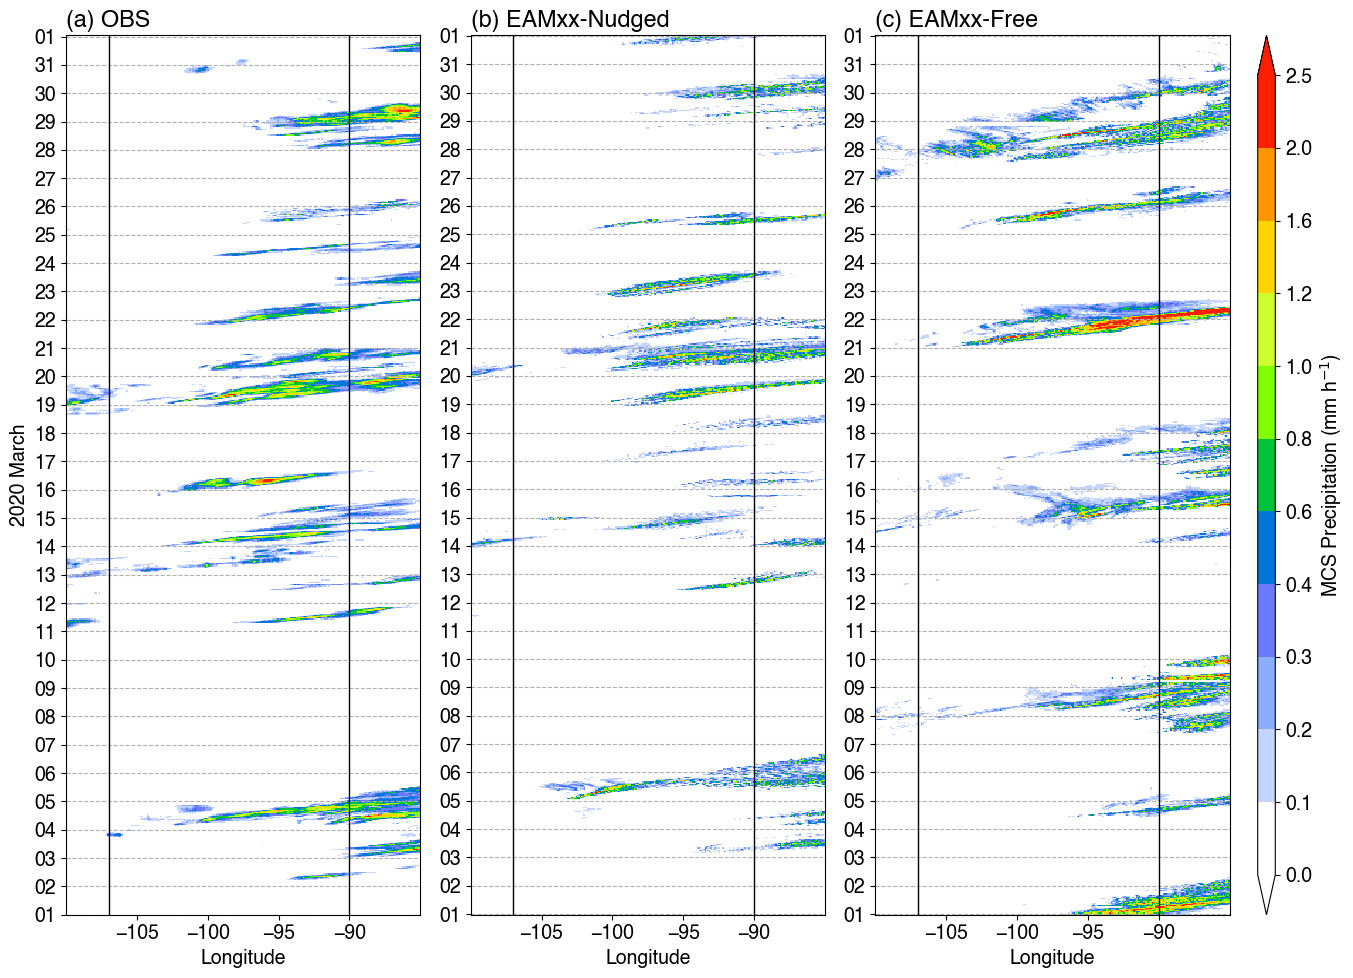

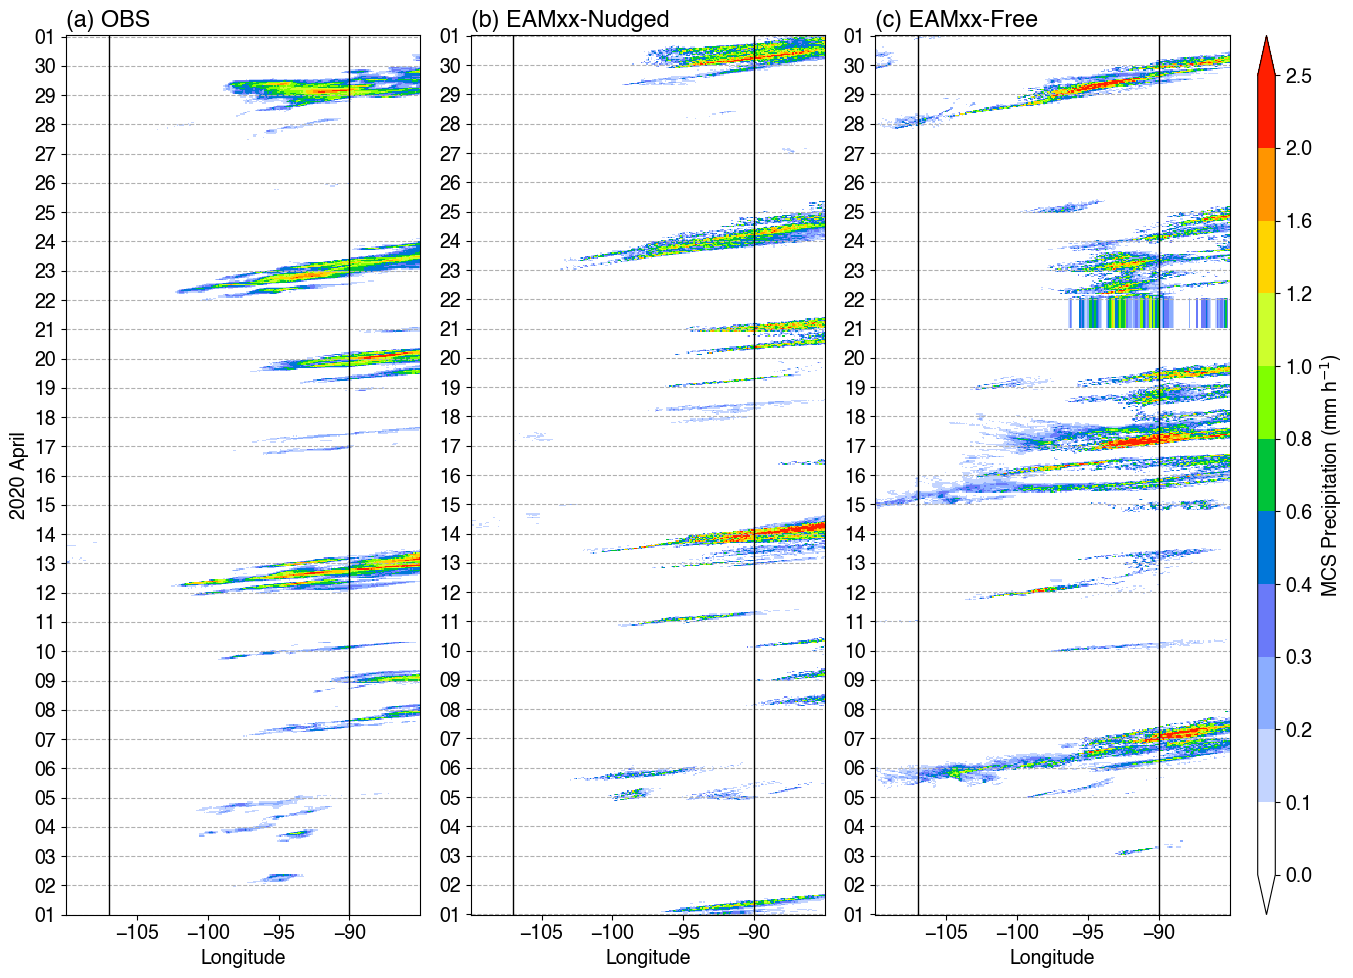

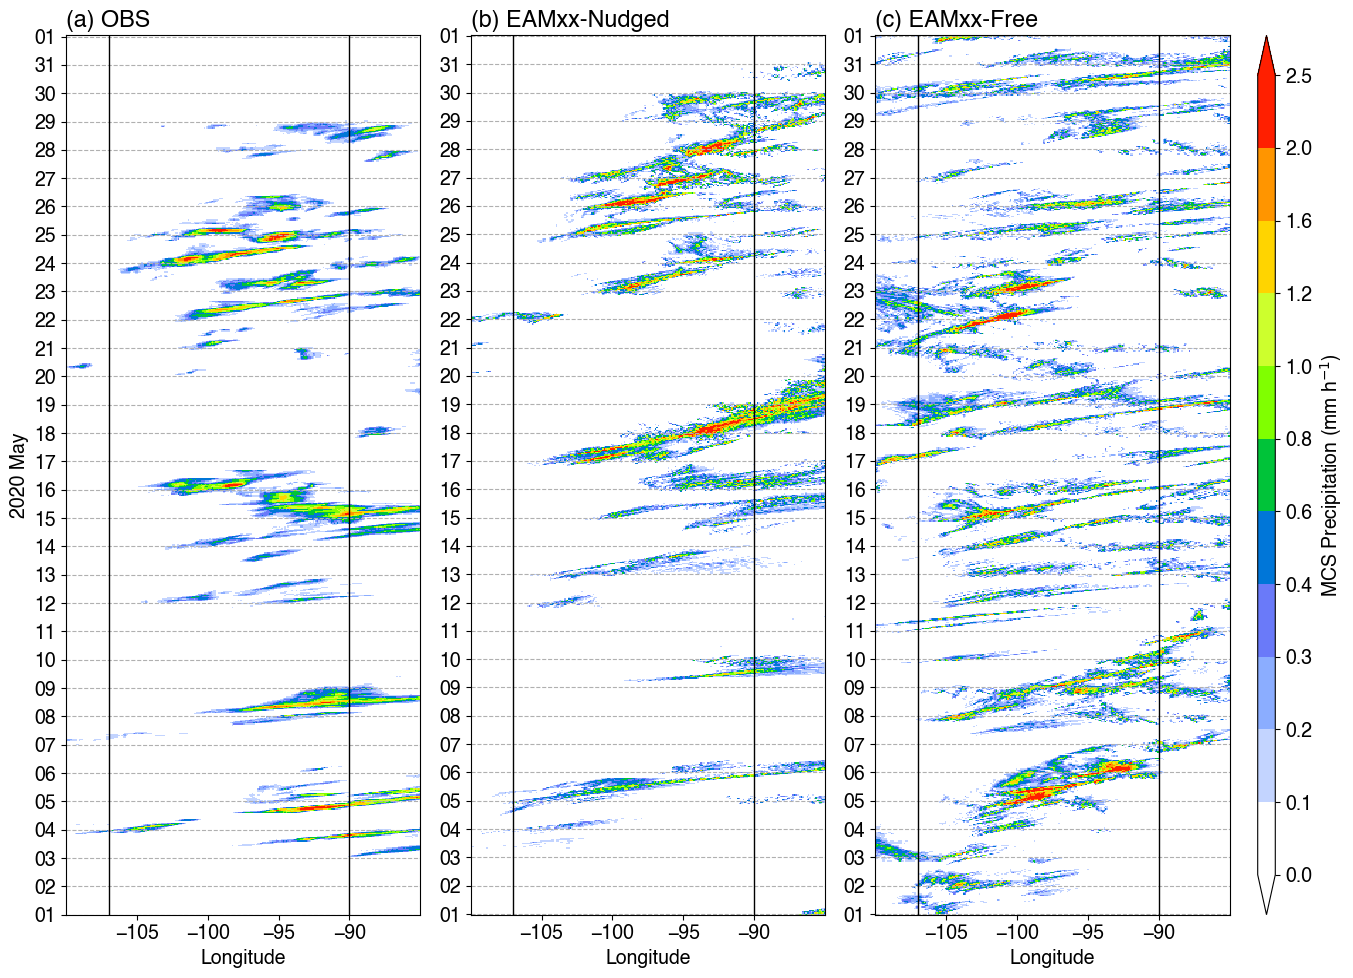

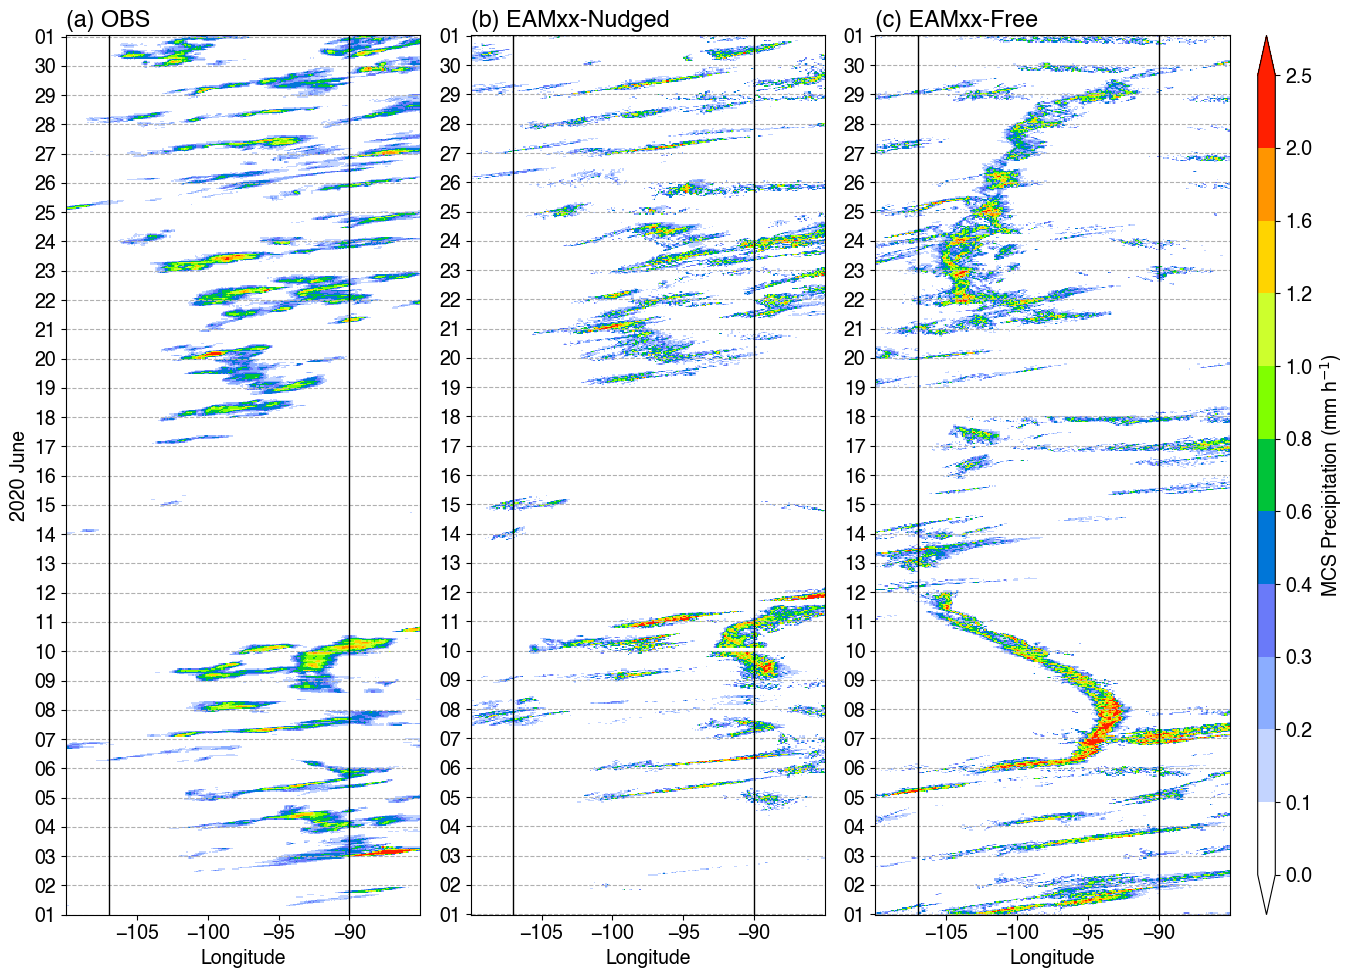

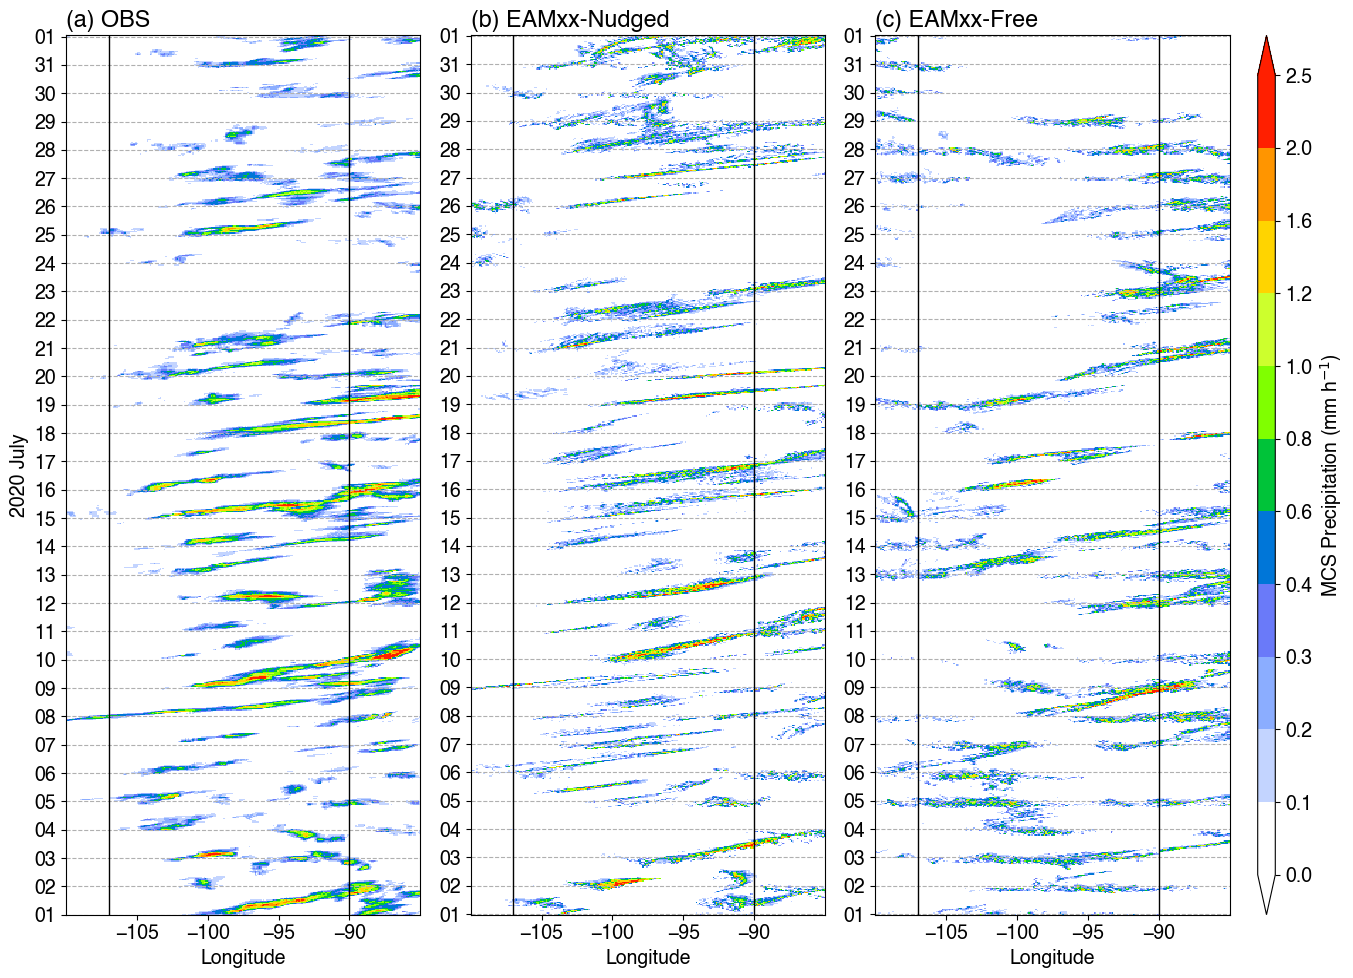

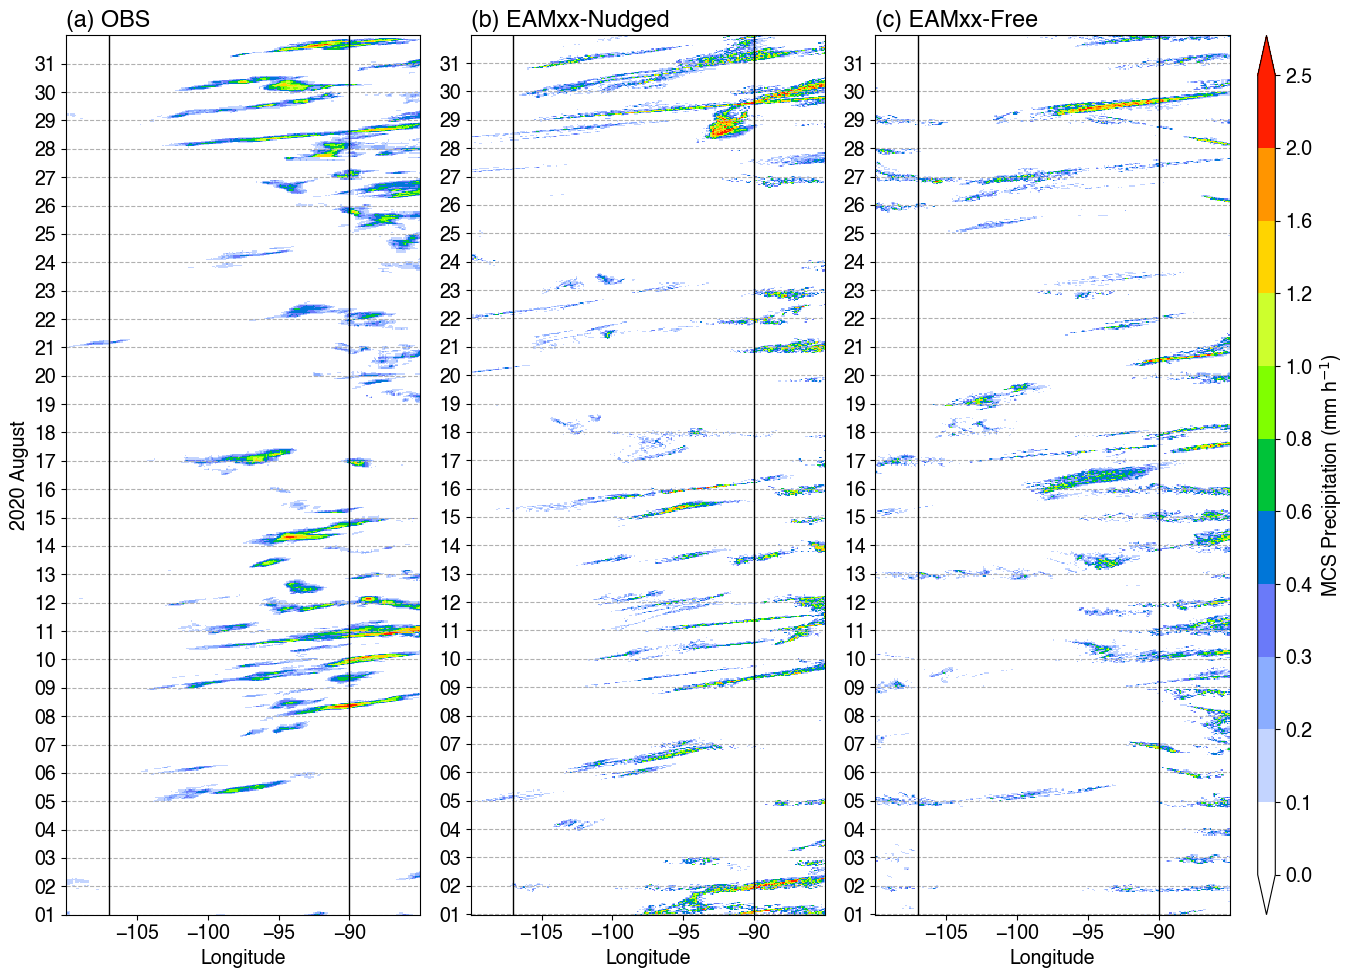

In [64]:
# Define start/end dates to plot monthly Hovmoller
datetime_range = pd.to_datetime(['2020-03-01T00', '2020-08-01T00'])
# Make start date of each month
sdates = pd.date_range(start=min(datetime_range), end=max(datetime_range), freq='MS')
# Make end date of each month: 1 month after
edates = pd.date_range(start=min(datetime_range) + pd.DateOffset(months=1), periods=len(sdates), freq='MS')

lonarr = [lon_obs, lon_m1, lon_m2]
cblabel = 'MCS Precipitation (mm h$^{-1}$)'
levels = [0,0.1,0.2,0.3,0.4,0.6,0.8,1,1.2,1.6,2,2.5]
cmap = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
titles = [f"(a) {name_map1['obs']}", f"(b) {name_map1['m1']}", f"(c) {name_map1['m2']}"]
    
# Loop over dates
for ii in range(len(sdates)):
    # print(ii, sdates[ii])
    sdate = sdates[ii].strftime('%Y-%m-%dT%H')
    edate = edates[ii].strftime('%Y-%m-%dT%H')
    sdate_figname = sdates[ii].strftime('%Y%m')
    
    ylabel = pd.to_datetime(sdates[ii]).strftime('%Y %B')
    ylabels = [ylabel, '', '']
    dataarr = [dsobs.mcs_precipitation.sel(time=slice(sdate, edate)), dsm1.mcs_precipitation.sel(time=slice(sdate, edate)), dsm2.mcs_precipitation.sel(time=slice(sdate, edate))]
    timearr = [dsobs.time.sel(time=slice(sdate, edate)), dsm1.time.sel(time=slice(sdate, edate)), dsm2.time.sel(time=slice(sdate, edate))]

    figname = f"{figdir}mcs_rainhov_obs_scream_{sdate_figname}.png"
    print(figname)
    fig = plot_3hov(dataarr, lonarr, timearr, levels, cmap, titles, ylabels, cblabel, figname)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202003.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202004.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202005.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202006.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202007.png
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/total_rainhov_obs_scream_202008.png


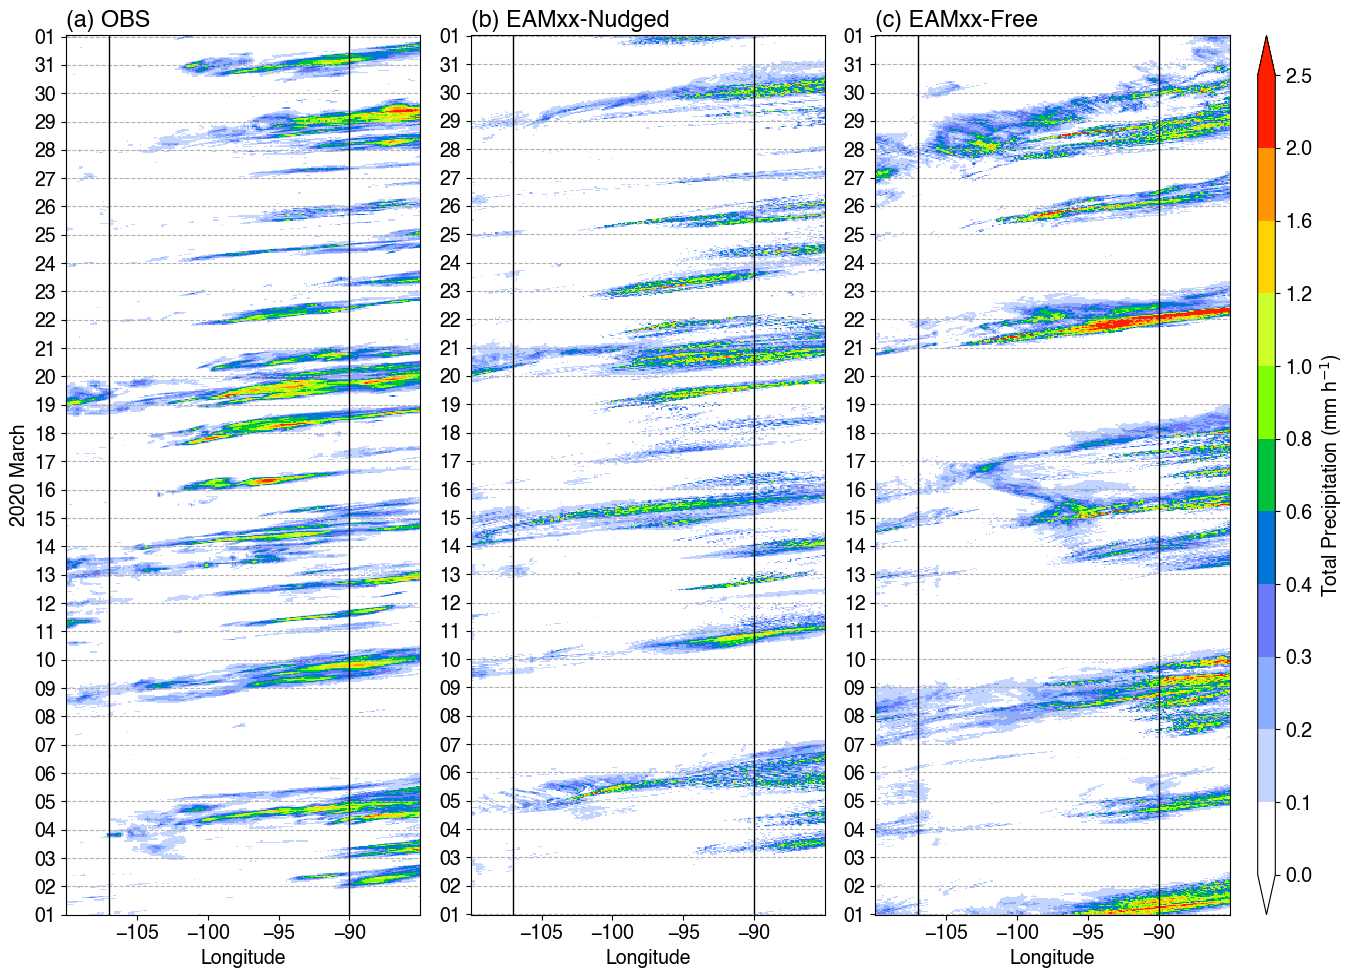

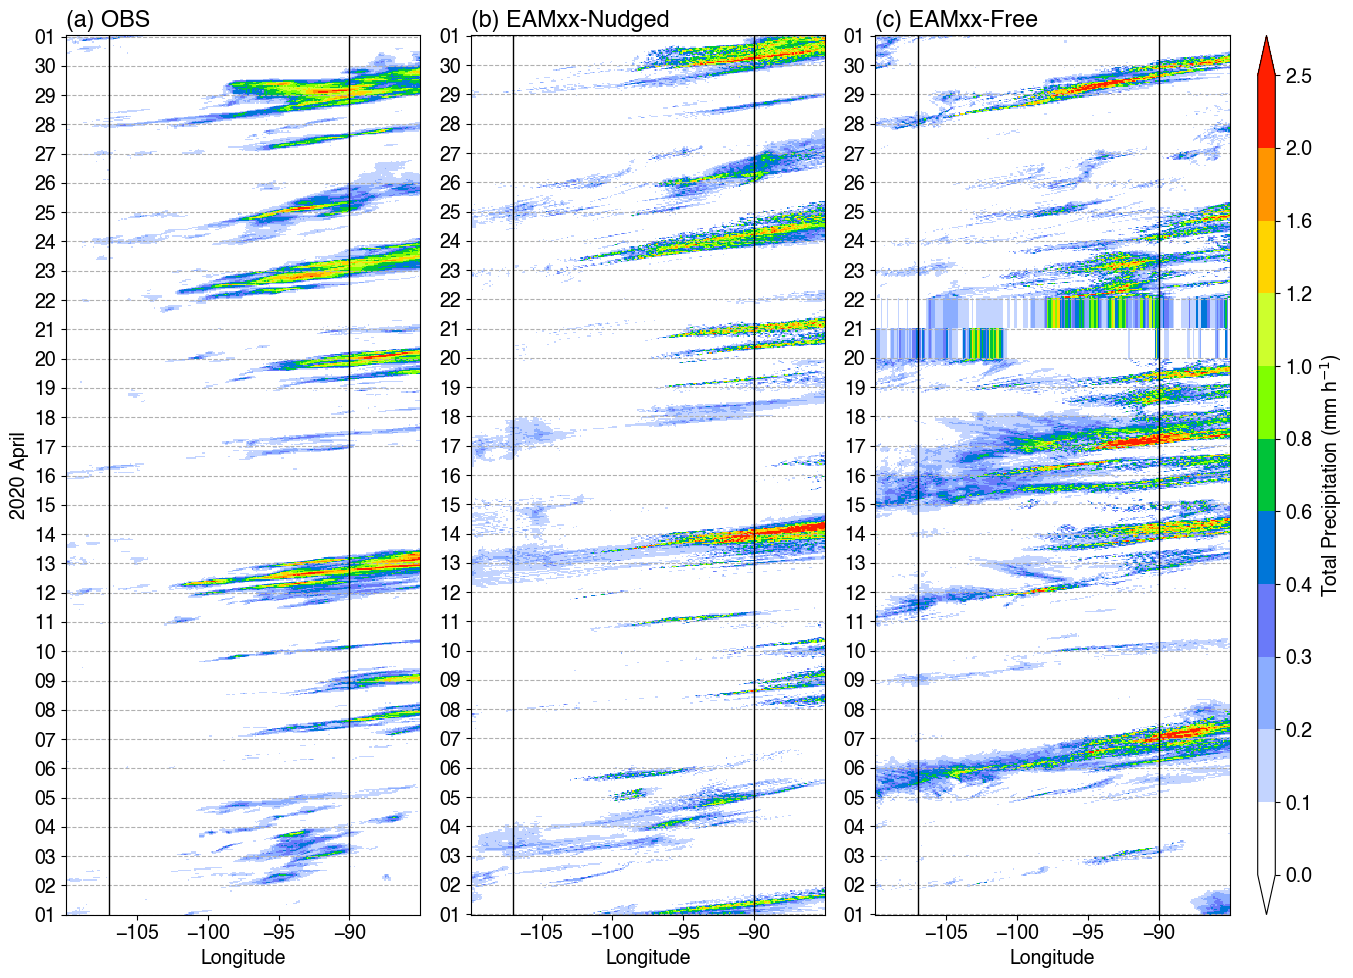

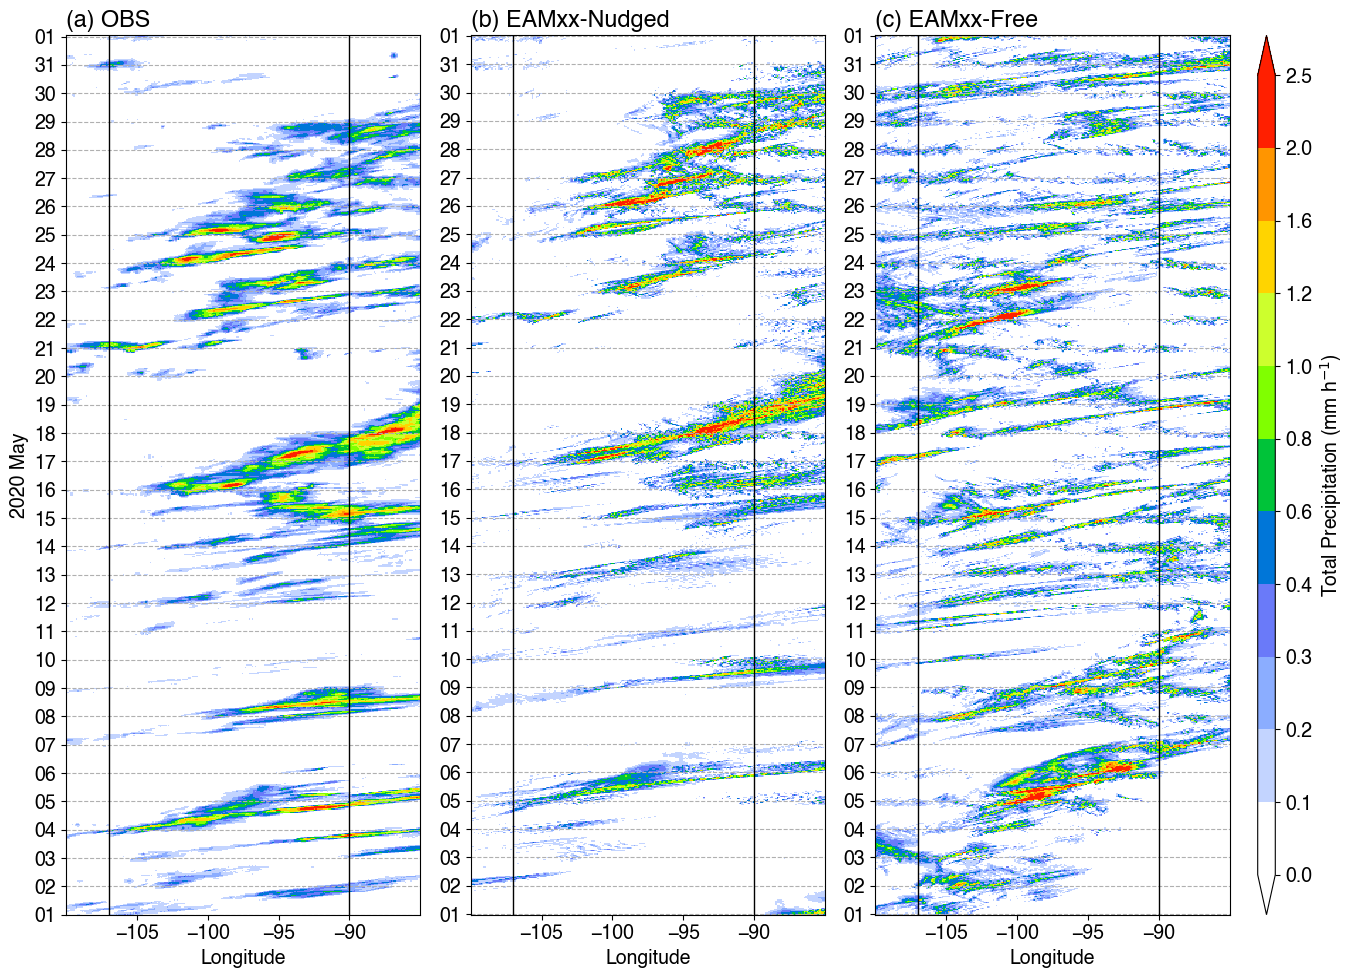

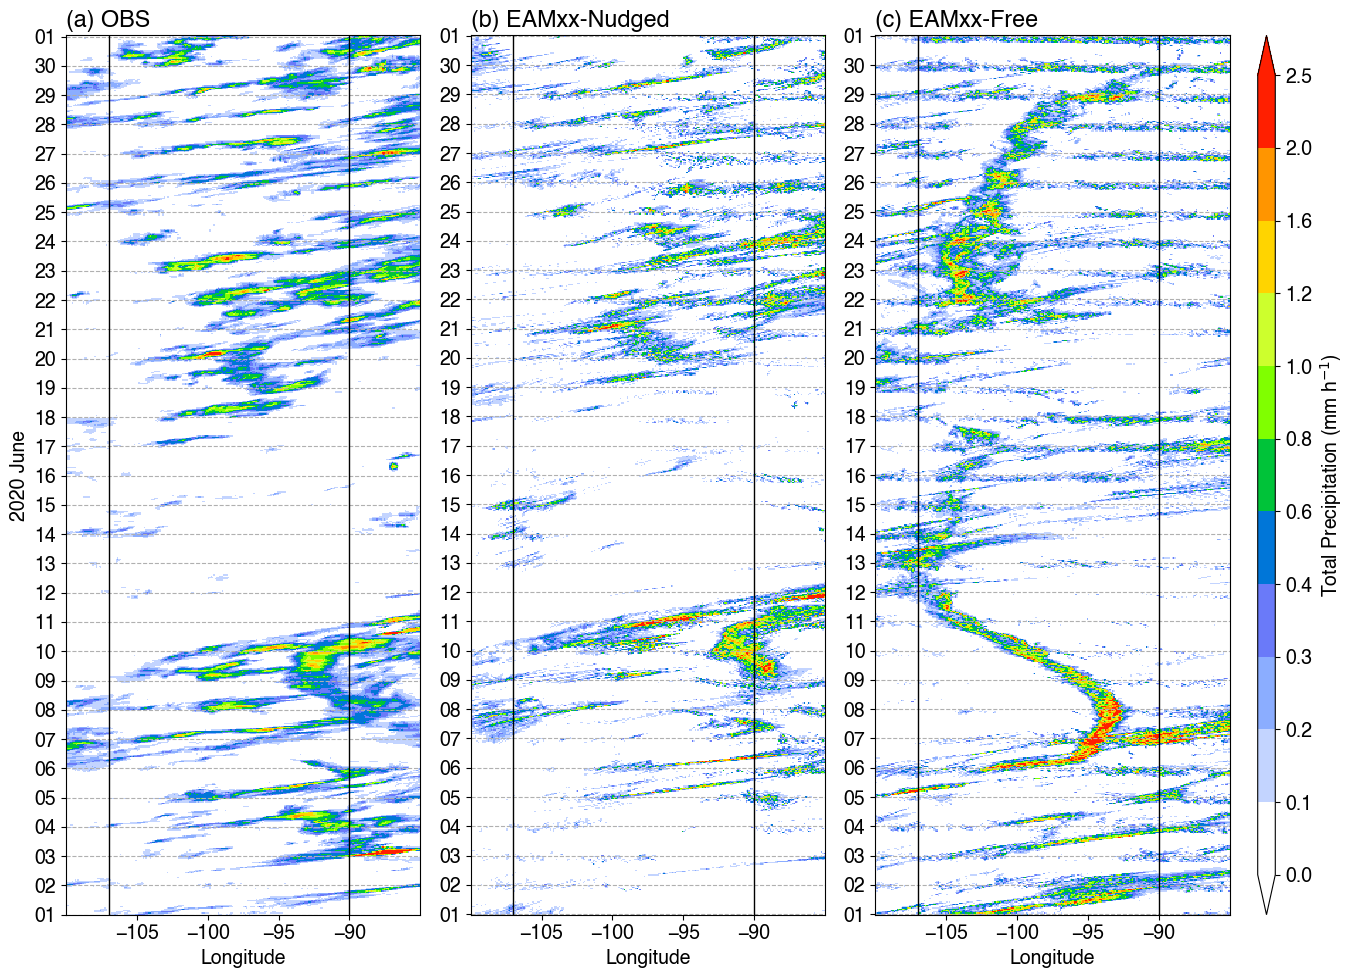

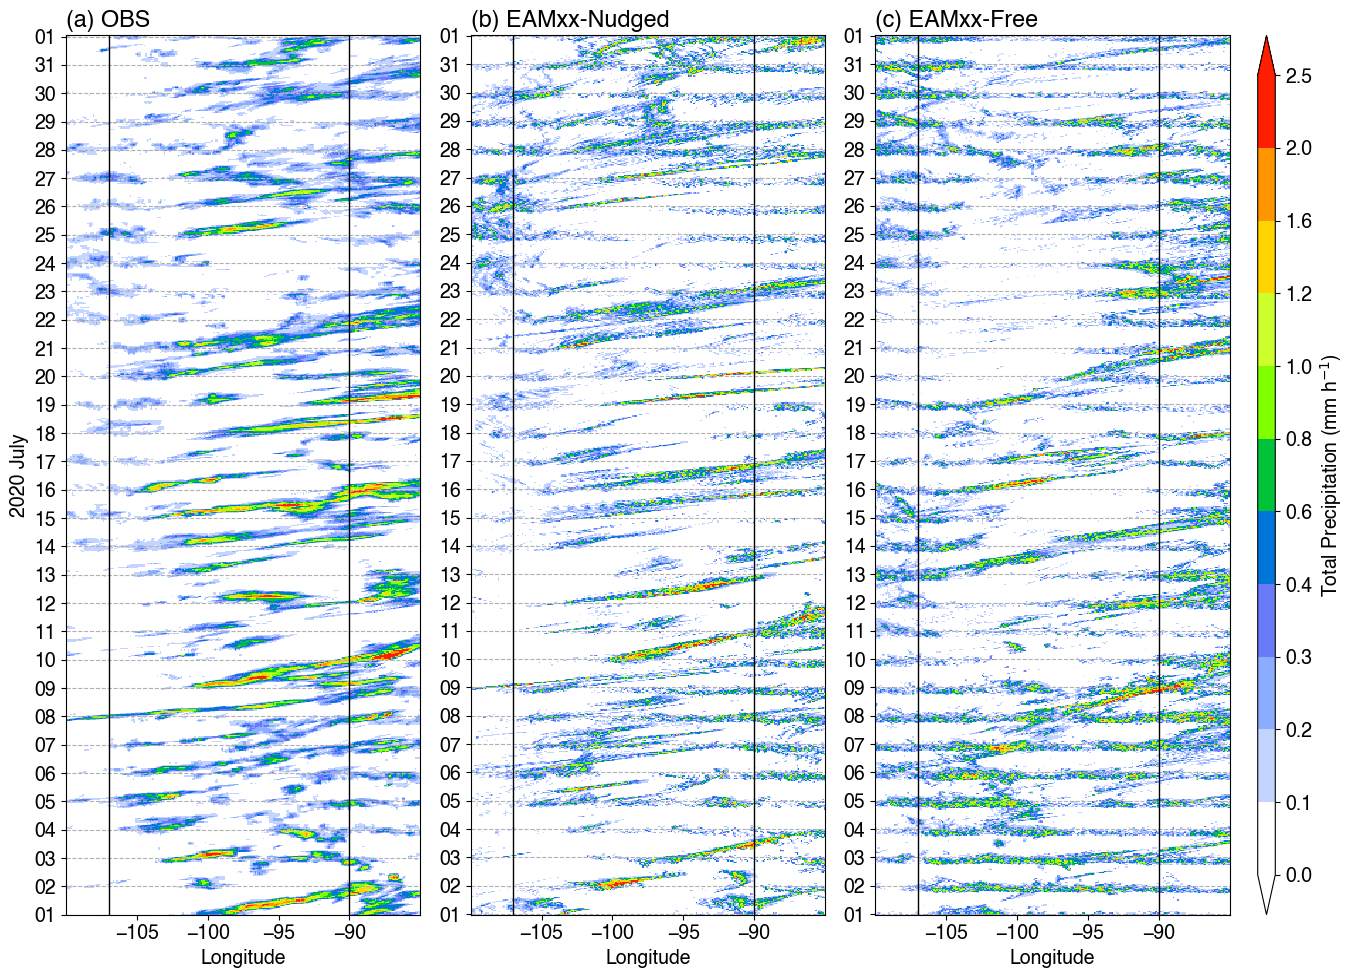

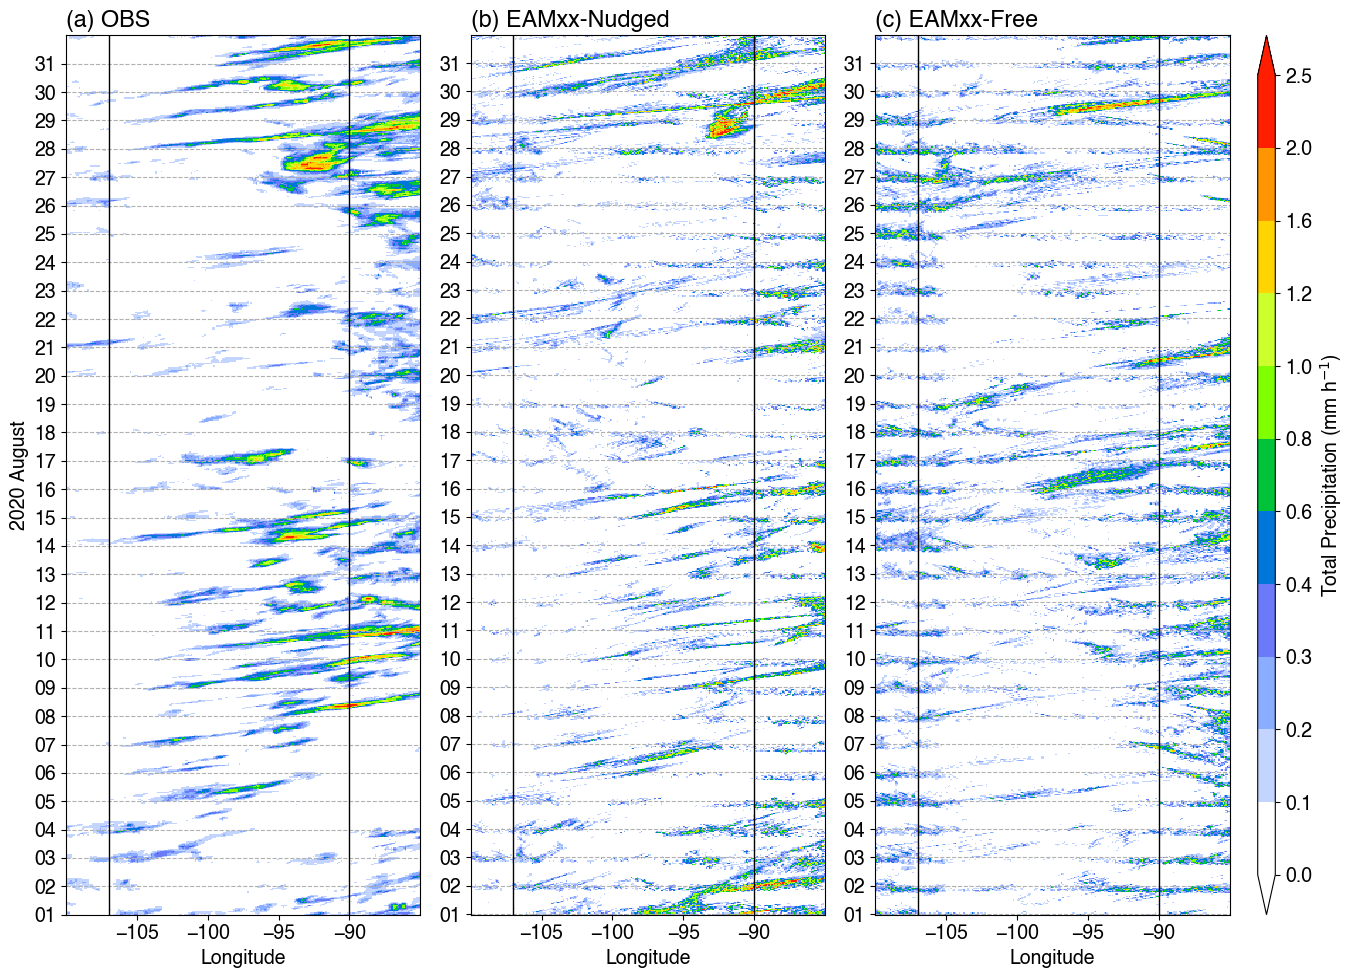

In [65]:
# Define start/end dates to plot monthly Hovmoller
datetime_range = pd.to_datetime(['2020-03-01T00', '2020-08-01T00'])
# Make start date of each month
sdates = pd.date_range(start=min(datetime_range), end=max(datetime_range), freq='MS')
# Make end date of each month: 1 month after
edates = pd.date_range(start=min(datetime_range) + pd.DateOffset(months=1), periods=len(sdates), freq='MS')

lonarr = [lon_obs, lon_m1, lon_m2]
cblabel = 'Total Precipitation (mm h$^{-1}$)'
levels = [0,0.1,0.2,0.3,0.4,0.6,0.8,1,1.2,1.6,2,2.5]
cmap = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
titles = [f"(a) {name_map1['obs']}", f"(b) {name_map1['m1']}", f"(c) {name_map1['m2']}"]
    
# Loop over dates
for ii in range(len(sdates)):
    # print(ii, sdates[ii])
    sdate = sdates[ii].strftime('%Y-%m-%dT%H')
    edate = edates[ii].strftime('%Y-%m-%dT%H')
    sdate_figname = sdates[ii].strftime('%Y%m')
    
    ylabel = pd.to_datetime(sdates[ii]).strftime('%Y %B')
    ylabels = [ylabel, '', '']
    dataarr = [dsobs.precipitation.sel(time=slice(sdate, edate)), dsm1.precipitation.sel(time=slice(sdate, edate)), dsm2.precipitation.sel(time=slice(sdate, edate))]
    timearr = [dsobs.time.sel(time=slice(sdate, edate)), dsm1.time.sel(time=slice(sdate, edate)), dsm2.time.sel(time=slice(sdate, edate))]

    figname = f"{figdir}total_rainhov_obs_scream_{sdate_figname}.png"
    print(figname)
    fig = plot_3hov(dataarr, lonarr, timearr, levels, cmap, titles, ylabels, cblabel, figname)

In [20]:
# totpcp_grd = ds_grd.precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# totpcp_nld = ds_nld.precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# totpcp_w1 = ds_w1.precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# totpcp_w2 = ds_w2.precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')

# mcspcp_grd = ds_grd.mcs_precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# mcspcp_nld = ds_nld.mcs_precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# mcspcp_w1 = ds_w1.mcs_precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')
# mcspcp_w2 = ds_w2.mcs_precipitation.sel(lon=slice(startlon, endlon)).mean(dim='lon')

In [66]:
# # Calculate time-mean precipitation
# pcp_thresh = 0.01
# totpcp_avg_grd = totpcp_grd.where(totpcp_grd > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# totpcp_avg_nld = totpcp_nld.where(totpcp_nld > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# totpcp_avg_w1 = totpcp_w1.where(totpcp_w1 > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# totpcp_avg_w2 = totpcp_w2.where(totpcp_w2 > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# totpcp_avg_bias_w1_grd = 100 * (totpcp_avg_w1 - totpcp_avg_grd)/totpcp_avg_grd
# totpcp_avg_bias_w1_nld = 100 * (totpcp_avg_w1 - totpcp_avg_nld)/totpcp_avg_nld

# totpcp_avg_diff_w2_w1 = 100 * (totpcp_avg_w2 - totpcp_avg_w1)/totpcp_avg_w1
# print(f'Total rain WRF CTL Bias (vs. StageIV): {totpcp_avg_bias_w1_grd:.0f}%')
# print(f'Total rain WRF CTL (vs. NLDAS): {totpcp_avg_bias_w1_nld:.0f}%')
# print(f'Total rain diff WRF (PGW - CTL): {totpcp_avg_diff_w2_w1:.01f}%')

In [67]:
# mcspcp_avg_grd = mcspcp_grd.where(mcspcp_grd > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# mcspcp_avg_nld = mcspcp_nld.where(mcspcp_nld > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# mcspcp_avg_w1 = mcspcp_w1.where(mcspcp_w1 > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# mcspcp_avg_w2 = mcspcp_w2.where(mcspcp_w2 > pcp_thresh).sel(time=slice(sdate, edate)).mean().values
# mcspcp_avg_bias_w1_grd = 100 * (mcspcp_avg_w1 - mcspcp_avg_grd)/mcspcp_avg_grd
# mcspcp_avg_bias_w1_nld = 100 * (mcspcp_avg_w1 - mcspcp_avg_nld)/mcspcp_avg_nld

# mcspcp_avg_diff_w2_w1 = 100 * (mcspcp_avg_w2 - mcspcp_avg_w1)/mcspcp_avg_w1

# print(f'MCS rain WRF CTL Bias (vs. StageIV): {mcspcp_avg_bias_w1_grd:.0f}%')
# print(f'MCS rain WRF CTL Bias (vs. NLDAS): {mcspcp_avg_bias_w1_nld:.0f}%')
# print(f'MCS rain diff WRF (PGW - CTL): {mcspcp_avg_diff_w2_w1:.01f}%')

In [68]:
# pd.to_datetime(sdate), pd.to_datetime(edate)

In [69]:
# # Read MCS track statistics file
# dstrack_grd = xr.open_dataset(grdmcsfile)
# stime_grd_all = dstrack_grd.base_time.isel(times=0)
# stime_grd_all
# np.where((stime_grd_all >= pd.to_datetime(sdate)) & (stime_grd_all <= pd.to_datetime(edate)))

In [70]:
# # Read MCS track statistics file
# dstrack_grd = xr.open_dataset(grdmcsfile)
# # dstrack_grd

# # Define a region to select tracks
# lonmin, lonmax = startlon, endlon
# latmin, latmax = startlat, endlat

# # Get MCS initiation time
# stime_grd_all = dstrack_grd.base_time.isel(times=0)
# smonth = stime_grd_all.dt.month

# # Get lat/lon at initial time
# ccs_lon0_grd_all = dstrack_grd.meanlon.isel(times=0)
# ccs_lat0_grd_all = dstrack_grd.meanlat.isel(times=0)

# # Find track indices initiated within SGP area during May
# # idx_grd = np.where((smonth == 5) & 
# idx_grd = np.where((stime_grd_all >= pd.to_datetime(sdate)) & (stime_grd_all <= pd.to_datetime(edate)) &
#                    (ccs_lon0_grd_all >= lonmin) & (ccs_lon0_grd_all <= lonmax) & 
#                    (ccs_lat0_grd_all >= latmin) & (ccs_lat0_grd_all <= latmax))[0]
# nmcs_grd = len(idx_grd)
# print(f'Number of MCS (GridRad): {nmcs_grd}')

# # Subset tracks
# stime_grd = stime_grd_all.sel(tracks=idx_grd)
# ccs_lon0_grd = ccs_lon0_grd_all.isel(tracks=idx_grd)
# ccs_lat0_grd = ccs_lat0_grd_all.isel(tracks=idx_grd)
# basetime_grd = dstrack_grd.base_time.isel(tracks=idx_grd)
# lifecycle_index_grd = dstrack_grd.lifecycle_index.isel(tracks=idx_grd)
# complete_flag_grd = dstrack_grd.lifecycle_complete_flag.isel(tracks=idx_grd)

# gentime_grd = []
# for itrack in range(0, nmcs_grd):
#     # Get lifecycle index for the track (0:CI, 1:genesis, 2:mature, 3:decay)
#     icomplete = complete_flag_grd.isel(tracks=itrack).values
#     ilifecycle = lifecycle_index_grd.isel(tracks=itrack).values.astype('int')
#     # If genesis index >= 0, get the PF lat/lon
#     if (ilifecycle[1] >= 0):
#         gentime_grd.append(basetime_grd.isel(tracks=itrack, times=ilifecycle[1]))

# # Convert back to numpy array
# # gentime_grd = np.array(gentime_grd)

In [71]:
# # Read MCS track statistics file
# dstrack_w1 = xr.open_dataset(wrfctl_mcsfile)

# # Define a region to select tracks
# lonmin, lonmax = startlon, endlon
# latmin, latmax = startlat, endlat

# # Get MCS initiation time
# stime_w1_all = dstrack_w1.base_time.isel(times=0)
# smonth = stime_w1_all.dt.month

# # Get lat/lon at initial time
# ccs_lon0_w1_all = dstrack_w1.meanlon.isel(times=0)
# ccs_lat0_w1_all = dstrack_w1.meanlat.isel(times=0)

# # Find track indices initiated within SGP area during May
# # idx_w1 = np.where((smonth == 5) & 
# idx_w1 = np.where((stime_w1_all >= pd.to_datetime(sdate)) & (stime_w1_all <= pd.to_datetime(edate)) &
#                    (ccs_lon0_w1_all >= lonmin) & (ccs_lon0_w1_all <= lonmax) & 
#                    (ccs_lat0_w1_all >= latmin) & (ccs_lat0_w1_all <= latmax))[0]
# nmcs_w1 = len(idx_w1)
# print(f'Number of MCS (WRF CTL): {nmcs_w1}')

# # Subset tracks
# stime_w1 = stime_w1_all.sel(tracks=idx_w1)
# ccs_lon0_w1 = ccs_lon0_w1_all.isel(tracks=idx_w1)
# ccs_lat0_w1 = ccs_lat0_w1_all.isel(tracks=idx_w1)
# basetime_w1 = dstrack_w1.base_time.isel(tracks=idx_w1)
# lifecycle_index_w1 = dstrack_w1.lifecycle_index.isel(tracks=idx_w1)
# complete_flag_w1 = dstrack_w1.lifecycle_complete_flag.isel(tracks=idx_w1)

# gentime_w1 = []
# for itrack in range(0, nmcs_w1):
#     # Get lifecycle index for the track (0:CI, 1:genesis, 2:mature, 3:decay)
#     icomplete = complete_flag_w1.isel(tracks=itrack).values
#     ilifecycle = lifecycle_index_w1.isel(tracks=itrack).values.astype('int')
#     # If genesis index >= 0, get the PF lat/lon
#     if (ilifecycle[1] >= 0):
#         gentime_w1.append(basetime_w1.isel(tracks=itrack, times=ilifecycle[1]))

In [72]:
# # Read MCS track statistics file
# dstrack_w2 = xr.open_dataset(wrfpgw_mcsfile)

# # Define a region to select tracks
# lonmin, lonmax = startlon, endlon
# latmin, latmax = startlat, endlat

# # Get MCS initiation time
# stime_w2_all = dstrack_w2.base_time.isel(times=0)
# smonth = stime_w2_all.dt.month

# # Get lat/lon at initial time
# ccs_lon0_w2_all = dstrack_w2.meanlon.isel(times=0)
# ccs_lat0_w2_all = dstrack_w2.meanlat.isel(times=0)

# # Find track indices initiated within SGP area during May
# # idx_w2 = np.where((smonth == 5) & 
# idx_w2 = np.where((stime_w2_all >= pd.to_datetime(sdate)) & (stime_w2_all <= pd.to_datetime(edate)) &
#                    (ccs_lon0_w2_all >= lonmin) & (ccs_lon0_w2_all <= lonmax) & 
#                    (ccs_lat0_w2_all >= latmin) & (ccs_lat0_w2_all <= latmax))[0]
# nmcs_w2 = len(idx_w2)
# print(f'Number of MCS (WRF PGW): {nmcs_w2}')

# # Subset tracks
# stime_w2 = stime_w2_all.sel(tracks=idx_w2)
# ccs_lon0_w2 = ccs_lon0_w2_all.isel(tracks=idx_w2)
# ccs_lat0_w2 = ccs_lat0_w2_all.isel(tracks=idx_w2)
# basetime_w2 = dstrack_w2.base_time.isel(tracks=idx_w2)
# lifecycle_index_w2 = dstrack_w2.lifecycle_index.isel(tracks=idx_w2)
# complete_flag_w2 = dstrack_w2.lifecycle_complete_flag.isel(tracks=idx_w2)

# gentime_w2 = []
# for itrack in range(0, nmcs_w2):
#     # Get lifecycle index for the track (0:CI, 1:genesis, 2:mature, 3:decay)
#     icomplete = complete_flag_w2.isel(tracks=itrack).values
#     ilifecycle = lifecycle_index_w2.isel(tracks=itrack).values.astype('int')
#     # If genesis index >= 0, get the PF lat/lon
#     if (ilifecycle[1] >= 0):
#         gentime_w2.append(basetime_w2.isel(tracks=itrack, times=ilifecycle[1]))

In [73]:
# (nmcs_w2 - nmcs_w1) / nmcs_w1

In [74]:
# fracdiff_totpcp = 100 * (totpcp_avg_w2 - totpcp_avg_w1) / totpcp_avg_w1
# fracdiff_mcspcp = 100 * (mcspcp_avg_w2 - mcspcp_avg_w1) / mcspcp_avg_w1
# print(f'{fracdiff_totpcp:.0f}%, {fracdiff_mcspcp:.0f}%')

In [75]:
# # MCS precipitation fraction
# mcspcpfrac_grd = 100 * mcspcp_grd.sum().data / totpcp_grd.sum().data
# mcspcpfrac_nld = 100 * mcspcp_nld.sum().data / totpcp_nld.sum().data
# mcspcpfrac_w1 = 100 * mcspcp_w1.sum().data / totpcp_w1.sum().data
# mcspcpfrac_w2 = 100 * mcspcp_w2.sum().data / totpcp_w2.sum().data
# print(f'MCS precipitation fraction')
# print(f'GridRad: {mcspcpfrac_grd:.0f}%, NLDAS: {mcspcpfrac_nld:.0f}%')
# print(f'CTL: {mcspcpfrac_w1:.0f}%, PGW: {mcspcpfrac_w2:.0f}%')

In [76]:
# stime_corr = '2015-05-04T00'
# etime_corr = '2015-05-31T23'
# totpcp_grd_sub = totpcp_grd.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# totpcp_nld_sub = totpcp_nld.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# totpcp_w1_sub = totpcp_w1.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# totpcp_w2_sub = totpcp_w2.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')

In [77]:
# mcspcp_grd_sub = mcspcp_grd.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# mcspcp_nld_sub = mcspcp_nld.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# mcspcp_w1_sub = mcspcp_w1.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')
# mcspcp_w2_sub = mcspcp_w2.sel(time=slice(stime_corr, etime_corr)).resample(time='1H', skipna=True).nearest(tolerance='1H')

In [78]:
# mcspcp_grd_sub.shape, mcspcp_nld_sub.shape, mcspcp_w1_sub.shape, mcspcp_w2_sub.shape

In [79]:
# # Calculate Pearson correlation coefficient
# rho_totpcp_grd_nld = np.corrcoef(totpcp_grd_sub, totpcp_nld_sub)
# coef_totpcp_grd_nld = rho_totpcp_grd_nld[0,1]

# rho_totpcp_w1_grd = np.corrcoef(totpcp_w1_sub, totpcp_grd_sub)
# coef_totpcp_w1_grd = rho_totpcp_w1_grd[0,1]

# rho_totpcp_w2_grd = np.corrcoef(totpcp_w2_sub, totpcp_grd_sub)
# coef_totpcp_w2_grd = rho_totpcp_w2_grd[0,1]

# rho_totpcp_w2_w1 = np.corrcoef(totpcp_w2_sub, totpcp_w1_sub)
# coef_totpcp_w2_w1 = rho_totpcp_w2_w1[0,1]

# print(f'Total precipitaiton correlation')
# print(f'[GridRad vs. NLDAS]: {coef_totpcp_grd_nld:.02f}')
# print(f'[CTL vs. GridRad]: {coef_totpcp_w1_grd:.02f}')
# print(f'[PGW vs. GridRad]: {coef_totpcp_w2_grd:.02f}')
# print(f'[PGW vs. CTL]: {coef_totpcp_w2_w1:.02f}')

In [80]:
# # Calculate Pearson correlation coefficient
# rho_mcspcp_grd_nld = np.corrcoef(mcspcp_grd_sub, mcspcp_nld_sub)
# coef_mcspcp_grd_nld = rho_mcspcp_grd_nld[0,1]

# rho_mcspcp_w1_grd = np.corrcoef(mcspcp_w1_sub, mcspcp_grd_sub)
# coef_mcspcp_w1_grd = rho_mcspcp_w1_grd[0,1]

# rho_mcspcp_w2_grd = np.corrcoef(mcspcp_w2_sub, mcspcp_grd_sub)
# coef_mcspcp_w2_grd = rho_mcspcp_w2_grd[0,1]

# rho_mcspcp_w2_w1 = np.corrcoef(mcspcp_w2_sub, mcspcp_w1_sub)
# coef_mcspcp_w2_w1 = rho_mcspcp_w2_w1[0,1]

# print(f'MCS precipitaiton correlation')
# print(f'[GridRad vs. NLDAS]: {coef_mcspcp_grd_nld:.02f}')
# print(f'[CTL vs. GridRad]: {coef_mcspcp_w1_grd:.02f}')
# print(f'[PGW vs. GridRad]: {coef_mcspcp_w2_grd:.02f}')
# print(f'[PGW vs. CTL]: {coef_mcspcp_w2_w1:.02f}')

In [81]:
# # RMSE
# rmse_totpcp_grd_nld = np.sqrt(np.nanmean((totpcp_grd_sub - totpcp_nld_sub)**2))
# rmse_totpcp_w1_grd = np.sqrt(np.nanmean((totpcp_w1_sub - totpcp_grd_sub)**2))

# rmse_mcspcp_grd_nld = np.sqrt(np.nanmean((mcspcp_grd_sub - mcspcp_nld_sub)**2))
# rmse_mcspcp_w1_grd = np.sqrt(np.nanmean((mcspcp_w1_sub - mcspcp_grd_sub)**2))

# print('Total precipitation RMSE')
# print(f'[GridRad vs. NLDAS]: {rmse_totpcp_grd_nld:.02f}')
# print(f'[CTL vs. GridRad]: {rmse_totpcp_w1_grd:.02f}')

# print('MCS precipitation RMSE')
# print(f'[GridRad vs. NLDAS]: {rmse_mcspcp_grd_nld:.02f}')
# print(f'[CTL vs. GridRad]: {rmse_mcspcp_w1_grd:.02f}')

In [82]:
# # Calculate the mean relative error
# relerr_totpcp_w1_grd = np.nanmean(np.abs((totpcp_grd_sub - totpcp_w1_sub) / totpcp_grd_sub)) * 100
# relerr_totpcp_w1_grd

In [83]:
# relerr_totpcp_w1_grd = 100 * np.nanmean(np.abs((totpcp_w1_sub - totpcp_grd_sub) / totpcp_grd_sub))
# relerr_totpcp_w1_grd

In [84]:
# mean_squared_error(totpcp_grd_sub, totpcp_w1_sub, squared=False) 

In [85]:
# # Calculate differences between PGW & CTL
# totpcp_w2_w1 = totpcp_w2 - totpcp_w1
# mcspcp_w2_w1 = mcspcp_w2 - mcspcp_w1

In [86]:
# mcspcpfrac_w2_w1 = 100 * (mcspcp_w2 - mcspcp_w1) / mcspcp_w1
# # mcspcpfrac_w2_w1, mcspcp_w1
# mcspcpfrac_w2_w1 = mcspcpfrac_w2_w1.where(np.abs(mcspcpfrac_w2_w1) <= 500, other=np.NaN)
# # mcspcpfrac_w2_w1 = mcspcpfrac_w2_w1.where(mcspcp_w1 > 0.01, other=np.NaN)

In [87]:
# mcspcp_w1_6hourly = mcspcp_w1.resample(time='6H', skipna=True).mean(keep_attrs=True)
# mcspcp_w2_6hourly = mcspcp_w2.resample(time='6H', skipna=True).mean(keep_attrs=True)

# mcspcpfrac_w2_w1_6hourly = 100 * (mcspcp_w2_6hourly - mcspcp_w1_6hourly) / mcspcp_w1_6hourly
# mcspcpfrac_w2_w1_6hourly = mcspcpfrac_w2_w1_6hourly.where(np.abs(mcspcpfrac_w2_w1_6hourly) <= 500, other=np.NaN)

# # mcspcpfrac_w2_w1_roll = mcspcpfrac_w2_w1_6hourly.rolling(time=3, min_periods=1).mean()
# mcspcpfrac_w2_w1_6hourly.plot()

In [88]:
# mcspcp_w1_6hourly = mcspcp_w1.rolling(time=6).mean(keep_attrs=True)
# mcspcp_w2_6hourly = mcspcp_w2.rolling(time=6).mean(keep_attrs=True)
# time_6hourly = mcspcp_w1_6hourly.time

# rr_thresh = 0.05
# mcspcp_w1_6hourly = mcspcp_w1_6hourly.where(mcspcp_w1_6hourly > rr_thresh, other=np.NaN)
# mcspcp_w2_6hourly = mcspcp_w2_6hourly.where(mcspcp_w2_6hourly > rr_thresh, other=np.NaN)

# mcspcpfrac_w2_w1_6hourly = 100 * (mcspcp_w2_6hourly - mcspcp_w1_6hourly) / mcspcp_w1_6hourly
# # mcspcpfrac_w2_w1_6hourly = mcspcpfrac_w2_w1_6hourly.where(np.abs(mcspcpfrac_w2_w1_6hourly) <= 500, other=np.NaN)
# # mcspcpfrac_w2_w1_6hourly = mcspcpfrac_w2_w1_6hourly.where(mcspcp_w1_6hourly > 0.01, other=np.NaN)
# timediff_6hourly = mcspcpfrac_w2_w1_6hourly.time

# fig, ax1 = plt.subplots(figsize=(10,2))
# mcspcp_w2_w1.plot(color='k', ax=ax1)
# # ax1.plot(time_6hourly, mcspcp_w1_6hourly, color='k')

# ax2 = ax1.twinx()
# ax2.plot(timediff_6hourly, mcspcpfrac_w2_w1_6hourly, color='r')
# ax2.set_ylim(-150, 200)

In [89]:
# fig = plt.figure(figsize=(10,2))
# totpcp_w2_w1.plot(color='k')
# mcspcp_w2_w1.plot(color='r')

## Plot domain mean precipitaiton time series

In [90]:
# mpl.rcParams['font.size'] = 16
# mpl.rcParams['font.family'] = 'Helvetica'

# fig = plt.figure(figsize=[16,12], dpi=100)
# # fig, axes = plt.subplots(3, 1, figsize=[16,12], dpi=100)
# dateinterval = 2
# markersize = 4

# ax1 = plt.subplot(311)
# # ax1 = axes[0]
# dfmt = mpl.dates.DateFormatter('%m/%d')
# days = mpl.dates.DayLocator(interval=dateinterval)
# # days = mpl.dates.DayLocator(bymonthday=dom)
# ax1.xaxis.set_major_formatter(dfmt)
# ax1.xaxis.set_major_locator(days)
# colors = {'grd':'k', 'nld':'dimgray', 'wrf1':'dodgerblue', 'wrf2':'tomato'}

# miss_sdate = '2015-05-17T01'
# miss_edate = '2015-05-18T22'
# linewidth = 3
# fontsize_leg = 13

# ax1.plot(totpcp_grd.time, totpcp_grd, '-', lw=linewidth, color=colors['grd'], markersize=markersize, label=f'StageIV ({totpcp_avg_grd:.2f})')
# ax1.plot(totpcp_nld.time, totpcp_nld, '-', lw=linewidth, color=colors['nld'], markersize=markersize, label=f'NLDAS ({totpcp_avg_nld:.2f})')
# ax1.plot(totpcp_w1.time, totpcp_w1, '-', lw=linewidth, color=colors['wrf1'], markersize=markersize, label=f'WRF CTL ({totpcp_avg_w1:.2f})')
# ax1.plot(totpcp_w2.time, totpcp_w2, '-', lw=linewidth, color=colors['wrf2'], markersize=markersize, label=f'WRF PGW ({totpcp_avg_w2:.2f}, +{fracdiff_totpcp:.0f}%)')
# # Plot missing radar period
# ax1.axvspan(pd.Timestamp(miss_sdate),pd.Timestamp(miss_edate),color='darkgray',alpha=0.3)
# # ax1.annotate('Missing Radar', xy=(pd.Timestamp('2015-5-18T'),1.3), xytext=(pd.Timestamp('2015-5-18T'),1.25), ha='left', fontsize=18, color='k')
# # ax1.text(pd.Timestamp('2015-5-18T'), 1.3, 'Missing GridRad Data', ha='center', fontsize=fontsize_leg, color='k')
# ax1.legend(loc='upper right', ncol=2, fontsize=fontsize_leg)
# ax1.grid(ls='--')
# ax1.set_ylim(0,1.5)
# ax1.set_title('(a) Total Precipitation', loc='left')
# ax1.set_ylabel('Precipitation (mm h$^{-1}$)')
# ax1.set_xlim(pd.Timestamp(sdate), pd.Timestamp(edate))
# # Setup inset map
# proj = ccrs.LambertConformal()
# data_proj = ccrs.PlateCarree()
# # proj = ccrs.PlateCarree()
# axins = inset_axes(ax1, width="20%", height="55%", loc="upper left", 
#                    axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=0.2, 
#                    axes_kwargs=dict(projection=proj))
# # axins.set_extent([-108, -87, 22, 42], ccrs.Geodetic())
# axins.set_extent([-112, -85, 23, 43], ccrs.Geodetic())
# # to get the effect of having just the states without a map "background"
# # turn off the outline and background patches
# # axins.background_patch.set_visible(False)
# # axins.outline_patch.set_visible(False)
# axins.patch.set_visible(False)
# axins.spines['geo'].set_visible(False)
# land = cfeature.NaturalEarthFeature('physical', 'land', '50m')
# states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', '50m')
# axins.add_feature(land, linewidth=1, edgecolor='k', facecolor=cfeature.COLORS['land'], zorder=2)
# axins.add_feature(states, linewidth=1, edgecolor='k', facecolor=cfeature.COLORS['land'], zorder=2)
# # box_avg = sgeom.box(minx=startlon, maxx=endlon, miny=28, maxy=40)
# # axins.add_geometries([box_avg], ccrs.Geodetic(), facecolor='tomato', edgecolor='none', alpha=0.2, zorder=6)
# # axins.add_geometries([box_avg], ccrs.Geodetic(), facecolor='none', edgecolor='r', lw=2, zorder=6)
# # Plot initial location
# axins.plot(ccs_lon0_grd, ccs_lat0_grd, 'o', color=colors['grd'], markersize=2, transform=ccrs.Geodetic(), zorder=5)
# axins.plot(ccs_lon0_w1, ccs_lat0_w1, 'o', color=colors['wrf1'], markersize=2, transform=ccrs.Geodetic(), zorder=5)
# axins.plot(ccs_lon0_w2, ccs_lat0_w2, 'o', color=colors['wrf2'], markersize=2, transform=ccrs.Geodetic(), zorder=5)
# # MCS track subset domain
# axins.text(-97, 25, 'MCS', color='r', fontsize=18, fontweight='bold', ha='center', transform=ccrs.Geodetic(), zorder=3)
# x1 = np.arange(startlon,endlon+0.01,0.1)
# y1 = np.repeat(startlat,len(x1))
# y2 = np.arange(startlat,endlat+0.01,0.1)
# x2 = np.repeat(endlon,len(y2))
# y3 = np.repeat(endlat,len(x1))
# x4 = np.repeat(startlon,len(y2))
# axins.plot(x1, y1, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x2, y2, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x1, y3, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x4, y2, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# # # WRF domain
# # # Define the vertices of the rectangle in the projection coordinates
# # x1, y1 = proj.transform_point(wlon_ll, wlat_ll, data_proj)
# # x2, y2 = proj.transform_point(wlon_ur, wlat_ur, data_proj)
# # # Plot rectangle
# # axins.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=1, edgecolor='tomato', zorder=4))

# ax2 = plt.subplot(312)
# # ax2 = axes[1]
# ax2.xaxis.set_major_formatter(dfmt)
# ax2.xaxis.set_major_locator(days)
# # rain_lines = []
# l1 = ax2.plot(mcspcp_grd.time, mcspcp_grd, '-', lw=linewidth, color=colors['grd'], markersize=markersize, label=f'StageIV ({mcspcp_avg_grd:.2f})')
# l2 = ax2.plot(mcspcp_nld.time, mcspcp_nld, '-', lw=linewidth, color=colors['nld'], markersize=markersize, label=f'NLDAS ({mcspcp_avg_nld:.2f})')
# l3 = ax2.plot(mcspcp_w1.time, mcspcp_w1, '-', lw=linewidth, color=colors['wrf1'], markersize=markersize, label=f'WRF CTL ({mcspcp_avg_w1:.2f})')
# l4 = ax2.plot(mcspcp_w2.time, mcspcp_w2, '-', lw=linewidth, color=colors['wrf2'], markersize=markersize, label=f'WRF PGW ({mcspcp_avg_w2:.2f}, +{fracdiff_mcspcp:.0f}%))')

# # Plot missing radar period
# ax2.axvspan(pd.Timestamp(miss_sdate),pd.Timestamp(miss_edate),color='darkgray',alpha=0.3)
# ax2.text(pd.Timestamp('2015-5-18T'), 1.2, 'Missing GridRad Data', ha='center', fontsize=fontsize_leg, color='k')
# # Plot MCS genesis times
# # for ii in range(len(gentime_grd)):
# #     ax2.axvline(pd.to_datetime(gentime_grd[ii].values), ymin=0, ymax=0.2, color='b', lw=1, zorder=3)
# #     ax2.plot(pd.to_datetime(gentime_grd[ii].values), 1.45, marker='v', markerfacecolor=colors['grd'], markeredgecolor=colors['grd'], markersize=6)
# # for ii in range(len(gentime_w1)):
# #     ax2.plot(pd.to_datetime(gentime_w1[ii].values), 1.4, marker='d', markerfacecolor=colors['wrf1'], markeredgecolor=colors['wrf1'], markersize=6)
# # Plot MCS initiation times
# for ii in range(len(stime_grd)):
#     ax2.plot(pd.to_datetime(stime_grd[ii].values), 1.45, marker='v', markerfacecolor=colors['grd'], markeredgecolor=colors['grd'], markersize=6)
# for ii in range(len(stime_w1)):
#     ax2.plot(pd.to_datetime(stime_w1[ii].values), 1.4, marker='o', markerfacecolor=colors['wrf1'], markeredgecolor=colors['wrf1'], markersize=6)
# for ii in range(len(stime_w2)):
#     ax2.plot(pd.to_datetime(stime_w2[ii].values), 1.35, marker='d', markerfacecolor=colors['wrf2'], markeredgecolor=colors['wrf2'], markersize=6)
# # ax2.set_xlabel('Date', fontsize=20)

# # Legend for MCS genesis
# legend_mcs = [mpl.lines.Line2D([0], [0], lw=0, marker='v', markerfacecolor=colors['grd'], markeredgecolor=colors['grd'], markersize=6, label='GRD MCS Init'),
#               mpl.lines.Line2D([0], [0], lw=0, marker='o', markerfacecolor=colors['wrf1'], markeredgecolor=colors['wrf1'], markersize=6, label='CTL MCS Init'),
#               mpl.lines.Line2D([0], [0], lw=0, marker='d', markerfacecolor=colors['wrf2'], markeredgecolor=colors['wrf2'], markersize=6, label='PGW MCS Init'),]
# # leg1 = plt.legend(loc='upper left', bbox_to_anchor=(0, 0.9))
# # leg2 = plt.legend(handles=legend_mcs, loc='upper right', bbox_to_anchor=(1, 0.9))
# leg1 = plt.legend(loc='upper right', bbox_to_anchor=(1, 0.9), ncol=2, fontsize=fontsize_leg)
# leg2 = plt.legend(handles=legend_mcs, loc='upper left', bbox_to_anchor=(0, 0.9), fontsize=fontsize_leg)
# ax2.add_artist(leg1)
# ax2.add_artist(leg2)
# ax2.grid(ls='--')
# ax2.set_ylim(0,1.5)
# ax2.set_title('(b) MCS Precipitation', loc='left')
# ax2.set_ylabel('Precipitation (mm h$^{-1}$)')
# ax2.set_xlim(pd.Timestamp(sdate), pd.Timestamp(edate))


# colors_diff = {'pos':'orangered', 'neg':'skyblue'}
# ax3 = plt.subplot(313)
# # ax3 = axes[2]
# ax3.xaxis.set_major_formatter(dfmt)
# ax3.xaxis.set_major_locator(days)
# # rain_lines = []
# # l1 = ax3.plot(totpcp_w2_w1.time, totpcp_w2_w1, '-', lw=linewidth, color=colors['grd'], markersize=markersize, label=f'PGW - CTL (Total)')
# # l2 = ax3.plot(mcspcp_w2_w1.time, mcspcp_w2_w1, '-', lw=linewidth, color=colors['wrf2'], markersize=markersize, label=f'PGW - CTL (MCS)')
# mcspcp_w2_w1_pos = mcspcp_w2_w1.where(mcspcp_w2_w1 > 0)
# mcspcp_w2_w1_neg = mcspcp_w2_w1.where(mcspcp_w2_w1 < 0)
# f2p = ax3.fill_between(mcspcp_w2_w1.time, mcspcp_w2_w1_pos, 0, facecolor=colors_diff['pos'])
# f2n = ax3.fill_between(mcspcp_w2_w1.time, mcspcp_w2_w1_neg, 0, facecolor=colors_diff['neg'])
# ax3.axhline(y=0, lw=1, ls='--', color='k')
# ax3.grid(ls='--')
# ax3.set_ylim(-0.2,0.4)
# ax3.set_title('(c) MCS Precipitation Changes (PGW - CTL)', loc='left')
# ax3.set_ylabel('$\Delta$Precipitation (mm h$^{-1}$)')
# ax3.set_xlim(pd.Timestamp(sdate), pd.Timestamp(edate))
# # ax3.legend(loc='upper right', fontsize=fontsize_leg)
# ax3.set_xlabel('Date', fontsize=20)

# # ax3b = ax3.twinx()
# # color_frac = 'crimson'
# # ax3b.plot(timediff_6hourly, mcspcpfrac_w2_w1_6hourly, lw=linewidth, color=color_frac, label='$\Delta$MCS %')
# # ax3b.set_ylabel('$\Delta$Precipitaiton (%)', color=color_frac)
# # ax3b.tick_params(axis='y', labelcolor=color_frac)
# # ax3b.set_ylim(-150, 200)

# fig.canvas.draw()
# fig.tight_layout()

# # figname = f'{figdir}sgp_domain_mean_rain_timeseries_stageiv_nldas_wrf_ctl_pgw_diff.png'
# figname = f'{figdir}sgp_domain_mean_rain_timeseries_stageiv_nldas_wrf_ctl_pgw_diff.pdf'
# fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')

NameError: name 'wlon_ll' is not defined

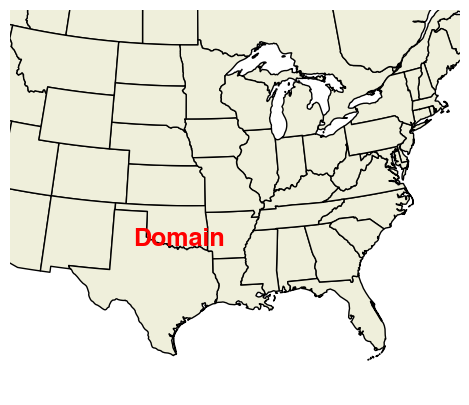

In [91]:
# Setup inset map
proj = ccrs.LambertConformal()
# proj = ccrs.PlateCarree()
# axins = inset_axes(ax1, width="30%", height="65%", loc="upper left", 
#                    axes_class=cartopy.mpl.geoaxes.GeoAxes, borderpad=0.5, 
#                    axes_kwargs=dict(map_projection=proj))
fig, axins = plt.subplots(1, figsize=[13,5], dpi=100, subplot_kw=dict(projection=proj))
axins.set_extent([-110, -75, 22, 50], ccrs.Geodetic())
# to get the effect of having just the states without a map "background"
# turn off the outline and background patches
# axins.background_patch.set_visible(False)
# axins.outline_patch.set_visible(False)
axins.patch.set_visible(False)
axins.spines['geo'].set_visible(False)
states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', '50m')
axins.add_feature(states, linewidth=1, edgecolor='k', facecolor=cfeature.COLORS['land'], zorder=2)
box_avg = sgeom.box(minx=startlon, maxx=endlon, miny=startlat, maxy=endlat)
# axins.add_geometries([box_avg], ccrs.Geodetic(), facecolor='tomato', edgecolor='none', alpha=0.2, zorder=6)
# axins.add_geometries([box_avg], ccrs.Geodetic(), facecolor='none', edgecolor='r', lw=2, zorder=6)
# axins.text(-97, 34, 'Domain', color='r', fontsize=18, fontweight='bold', ha='center', transform=ccrs.Geodetic(), zorder=10)
# axins.add_geometries([box_avg], ccrs.PlateCarree(), facecolor='tomato', edgecolor='none', alpha=0.2, zorder=3)
# axins.add_geometries([box_avg], ccrs.PlateCarree(), facecolor='none', edgecolor='r', lw=2, zorder=3)
axins.text(-97, 34, 'Domain', color='r', fontsize=18, fontweight='bold', ha='center', transform=ccrs.PlateCarree(), zorder=3)

# WRF domain
# Define the vertices of the rectangle in the projection coordinates
x1, y1 = proj.transform_point(wlon_ll, wlat_ll, data_proj)
x2, y2 = proj.transform_point(wlon_ur, wlat_ur, data_proj)
# Plot rectangle
axins.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=2, edgecolor='tomato', zorder=4))

# x1 = np.arange(startlon,endlon+0.01,0.1)
# y1 = np.repeat(startlat,len(x1))
# y2 = np.arange(startlat,endlat+0.01,0.1)
# x2 = np.repeat(endlon,len(y2))
# y3 = np.repeat(endlat,len(x1))
# x4 = np.repeat(startlon,len(y2))
# axins.plot(x1, y1, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x2, y2, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x1, y3, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)
# axins.plot(x4, y2, color='r', lw=2, transform=ccrs.PlateCarree(), zorder=4)